# Download and prepare `PA` (2005-2025)

**notebook version**: `3` (29 Jul 2026)

## ℹ️ About this notebook

Downloads screened atmospheric pressure `PA` from the InfluxDB database, **harmonises the units of
the two data sources**, merges them into one continuous series, applies the 2012 corrections and
stores the result to the external data folder. It also identifies the barometer from the logger
programs, checks the **absolute** level of the record against the barometric formula, and tests the
two hardware boundaries the record crosses.

Same structure as notebooks `01` (`SW_IN`), `02` (`TA`) and `03` (`PPFD_IN`), with three deliberate
differences, each explained where it happens:

1. **The two sources are stored in different units** (`kPa` and `Pa`). They are harmonised to `kPa`
   *before* anything is merged, plotted or summarised. This is the main thing this notebook does
   that the others do not.
2. **No gap-filling.** The measured record is almost complete, so the series is exported as
   measured. See "No gap-filling here" below.
3. **The record starts 2005-09-02**, when the archive begins. There is no `PA` for 2004 and most of
   2005, and none is invented, so unlike `01`-`03` the index does not begin at 2004-01-01.

**Output column:**

- `PA_T1_47_1` — atmospheric pressure in **kPa**, measured, corrected, with genuine gaps left as
  `NaN`

There is **no `FLAG_..._ISFILLED` column**: nothing is filled, so every non-null record is a
measurement and every gap is a real gap. This differs from `01`-`03`, which are gap-filled products
and carry a flag.

::: {.callout-important title="Known limitation: a level step at the January 2016 acquisition change"}
The section *Which sensor this is, and what the hardware changes did to it* establishes three
things about the tower logger replacement of January 2016: the record before it sits about
0.09 kPa above the record after it; the step is on the tower barometer and not on either reference,
because the two references do not move against each other; and the later era is the one that agrees
with the barometric formula, to within 0.03 kPa against two independent references.

The series is nevertheless exported **as measured**, with no homogenised second column. The step is
one part in a thousand of the value, and adding a rescaled column would change the set of columns
this product ships and the merged product built from it. A user who needs one absolute level across
the whole record should subtract the step from the records before 2016-01-21; a user comparing
`PA` within a year, or using it for air density in flux processing, is not affected at this size.
:::

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

## 📇 Data sources

- `PA_T1_47_1` — the exported variable. Tower 1, 47 m. `mst` (2005-2021) and `diive` (2022-2025).
  The two do not overlap.
- `PA_NABEL_H1_2_1` — a second barometer at the hut, 2 m, on the **NABEL** acquisition system. Used
  here as a diagnostic reference; *not* exported and *not* a driver, because nothing is gap-filled.
  Its value is that it is independent of the tower logger, which is what is needed to judge a
  tower-logger fault. It is nominally available to the end of 2018, but from July of that year the
  series merely repeats the tower series, so the notebook trims it — see *The NABEL reference stops
  being independent* below.
- `PA_LAE_MS` — MeteoSwiss Lägern station pressure (2.5 km, 845 m), **2004-2025**. A second
  independent diagnostic reference, read from the reference product (see `REFPATH`), that spans the
  whole record and so validates the years after NABEL stops. Stored in `hPa`; divided by 10 to
  `kPa`. Diagnostic only, never exported. `TA_LAE_MS` and `VP_LAE_MS` are read from the same file
  for the barometric formula, which needs the temperature and the humidity of the air column.
- `PA_H1_0_1` (2017-2019, kPa) also exists in the database but is not used: it is short, and it
  overlaps a period where `PA_T1_47_1` is already essentially complete.
- **The logger programs** — the six CR10X programs of 2004-2006 and the CR1000 program installed at
  the January 2016 changeover. They name the barometer and give its conversion, which the fieldbook
  does not. Read in the notebook, not quoted.
- **The GIN fieldbook** — the site maintenance record, read in the notebook and filtered there.

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- MeteoSwiss ... [MeteoSwiss](https://www.meteoswiss.admin.ch/) open data, station Lägern (LAE); produced by `10_REFERENCE`
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⚠️ The unit break, and why it is handled first

The two sources of `PA_T1_47_1` are stored in **different units**, differing by exactly a factor
of 1000, with a clean break at the 2021/2022 boundary and no overlap:

| source | n | period | median as stored | unit |
|---|---|---|---|---|
| `meteoscreening_mst` | 283,395 | 2005-09-02 -> 2021-12-31 | 93.33 | kPa |
| `meteoscreening_diive` | 70,012 | 2022-01-01 -> 2025-12-31 | 93,228.45 | Pa |

(The *medians* above are in the ratio 998.9 rather than 1000.0 because they cover different
years and pressure varies; it is the **unit** that differs by exactly 1000.)

Merging these two as they are would produce a series that jumps by three orders of magnitude in the
middle. Every heatmap, every `describe()`, every mean and standard deviation computed across the
break would be meaningless, and — worst of all — the result would still *look* like a number.

So the harmonisation runs **before the merge**, and it does not trust the calendar:

- The unit is decided **per source, from the magnitude of the data**, not from the split date.
  Surface pressure at CH-LAE (~690 m a.s.l.) is about 93 kPa = 930 hPa = 93,000 Pa, and those three
  candidates are three orders of magnitude apart, so the median identifies the unit unambiguously.
- The magnitude verdict is **cross-checked against the unit tag the database itself carries**
  (`units` is stored per series: `kPa` for `mst`, `Pa` for `diive`, `hPa` for NABEL). If the two
  disagree, the notebook **raises** rather than guessing.
- After conversion, the **full range** of every source must lie inside the plausible band, not just
  the median. A source that does not match raises.

A silent factor-1000 error is the single worst outcome this notebook could produce, so every path
through the helper either converts correctly or stops.

**Output unit is `kPa`**, which is the FLUXNET convention, what `diive`'s FLUXNET formatter documents
(`PA (kPa)`), what notebook `x-99` already declares when writing `Pa_1_1_1` for EddyPro, and what the
existing `11_METEO6` product carries.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "PA_T1_47_1"           # exported variable, tower 47 m
REFERENCE = "PA_NABEL_H1_2_1"   # hut barometer, diagnostics only, never exported

# PA measurements start 2005-09-02. The exported index starts there rather than at 2004-01-01:
# there is no pressure before it and none is reconstructed, so a 2004 index would begin with
# 20 months of nothing.
RECORD_START = '2005-09-02'
RECORD_END = '2025-12-31'

# Output: data files live in the external (untracked) data folder, with the same numeric prefix
# as this notebook. The name says neither GAPFILLED nor 2004, because it is neither.
OUTNAME = "05_METEO_PA_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Reference: MeteoSwiss Lägern station pressure (QFE), 2.5 km from the tower at 845 m. An
# independent diagnostic reference that spans the whole 2004-2025 record, so it can check the
# years after the NABEL barometer stops in 2018. Diagnostic only, never exported. Produced by
# 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb; addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "PA_LAE_MS"     # hPa in the reference file; divided by 10 to kPa where it is used
REFCOL_TA = "TA_LAE_MS"  # deg C, the air temperature of the column between station and tower
REFCOL_VP = "VP_LAE_MS"  # hPa, vapour pressure; humid air is lighter, so the check needs it

# --- Geometry, for the barometric check --------------------------------------------------------
# Pressure falls with height by a law with no free parameter, so these elevations turn into a
# prediction that the measured difference either meets or does not. They are inputs to a test, not
# assumptions the exported product rests on.
SITE_BASE_ELEVATION = 689.0  # m a.s.l., tower base
SENSOR_HEIGHT = 47.0         # m above ground, from the field name PA_T1_47_1
LAE_ELEVATION = 845.0        # m a.s.l., MeteoSwiss Laegern (from 10_REFERENCE)
HUT_HEIGHT = 2.0             # m above ground, from the field name PA_NABEL_H1_2_1

# --- Inputs for the sensor-identity section ----------------------------------------------------
# The site maintenance record, exported from GIN. It lives BESIDE the workflow folder, not inside
# it, because it is an input to many stages rather than the output of one.
FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

# Every surviving logger program that measures pressure at this tower, read rather than quoted, so
# the sensor identity and the conversion are re-derived on every run. All six CR10X programs carry
# the barometer; PROGRAM_AFTER is the CR1000 program installed at the January 2016 changeover.
_CSI = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
        r"\csi_loggerscripts")
PROGRAMS_CR10X = [_CSI + r"\LAEGEREN.20040526.CSI",
                  _CSI + r"\LAEGEREN.20040810.CSI",
                  _CSI + r"\LAEGEREN.20041228.CSI",
                  _CSI + r"\LAEGEREN.20050818.CSI",
                  _CSI + r"\LAEGEREN.20050914.CSI",
                  _CSI + r"\LAEGEREN.20060524.csi"]
PROGRAM_AFTER = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
                 r"\logger_scripts\ch-lae_idl_t1_47_1-Version_20160118\CH-LAE_iDL_T1_47_1.CR1")

# The tower logger was replaced during the outage that ends on this date, which the data, the
# program file name and the fieldbook all point to. Derived and asserted below, not assumed here.
ACQUISITION_CHANGE = '2016-01-21'


### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata
import html
import re
import textwrap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-29 01:24:52
diive version: v0.91.0


### Captions

Every table in this notebook carries a caption above it and every figure one below it, so that a reader meeting a number in the rendered page can tell what it is without reading the code that produced it. Both helpers are defined here, above the first cell that calls either, and are copied as-is from notebook `03`.

In [3]:
# Captions. Copied as-is from notebook 03, whose figcap carries the PlaceHolderLayoutEngine fix.
def tabcap(text, width=100):
    """Print a table caption, above the table it belongs to."""
    print(textwrap.fill(f"Table - {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn."""
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure - {text}", width)
    # An engine that still lays the figure out at draw time can make room for a caption itself.
    # plt.tight_layout() does NOT leave one: it executes once and leaves a PlaceHolderLayoutEngine
    # that never runs again, so a caption handed to supxlabel there lands on top of the tick
    # labels. Those figures take the manual branch below.
    _engine = fig.get_layout_engine()
    if _engine is not None and type(_engine).__name__ != 'PlaceHolderLayoutEngine':
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12          # inches; one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')

### 🧭 Unit harmonisation helper

`harmonise_to_kpa()` is the guard described above. It refuses to convert anything it cannot identify
with certainty, and it never looks at the date.

`PA_PLAUSIBLE_KPA` is deliberately generous (85-100 kPa). Recorded extremes at this site are
89.4-95.5 kPa, and the band only has to be tight enough to separate `kPa` from `hPa` from `Pa`,
which are 10x and 1000x apart.

In [4]:
# Plausible surface pressure at CH-LAE (~690 m a.s.l.). Wide enough to accept any real weather,
# far too narrow to accept a value that is off by a factor of 10 or 1000.
PA_PLAUSIBLE_KPA = (85.0, 100.0)

UNIT_FACTORS_TO_KPA = {'kPa': 1.0, 'hPa': 0.1, 'Pa': 0.001}


def harmonise_to_kpa(series: pd.Series, source: str, declared_unit: str | None = None) -> pd.Series:
    """Convert a pressure series to kPa, identifying its unit from the data itself.

    The unit is decided by magnitude, NOT by date: the median is multiplied by each candidate
    factor and exactly one result must land inside `PA_PLAUSIBLE_KPA`. `declared_unit` is the
    unit tag stored alongside the series in the database; when given it must agree with the
    magnitude verdict.

    Raises ValueError if the unit is ambiguous, if the declared and detected units disagree, or
    if any converted value falls outside the plausible band. Silently returning a series that is
    off by a factor of 1000 is the one outcome that must never happen.
    """
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data, cannot determine unit.")

    lo, hi = PA_PLAUSIBLE_KPA
    median = float(s.median())
    matches = [u for u, f in UNIT_FACTORS_TO_KPA.items() if lo <= median * f <= hi]
    if len(matches) != 1:
        raise ValueError(
            f"{source}: median {median:,.2f} is consistent with {matches or 'no'} unit(s), "
            f"expected exactly one. Surface pressure here is ~93 kPa / ~930 hPa / ~93,000 Pa.")
    detected = matches[0]

    if declared_unit is not None and declared_unit != detected:
        raise ValueError(
            f"{source}: the database declares '{declared_unit}' but the magnitude says "
            f"'{detected}' (median {median:,.2f}). Refusing to guess - check the source.")

    factor = UNIT_FACTORS_TO_KPA[detected]
    out = series * factor

    converted = out.dropna()
    if not (lo <= converted.min() and converted.max() <= hi):
        raise ValueError(
            f"{source}: after converting {detected} -> kPa the range is "
            f"{converted.min():.2f}..{converted.max():.2f} kPa, outside the plausible "
            f"{lo}..{hi} kPa. Not exporting this.")

    print(f"  {source:<26} {detected:>3} -> kPa (x{factor:g})   n={len(converted):>7,}   "
          f"median {float(converted.median()):7.3f}   "
          f"range {converted.min():.2f}..{converted.max():.2f}")
    return out

### 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

Three series are downloaded: the target from both of its data versions, and the NABEL reference.

The unit tag each series carries in the database is read back here and passed to
`harmonise_to_kpa()` as `declared_unit`, so the database's own claim and the data's magnitude have
to agree.

In [6]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PA']


def download(fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=MEASUREMENTS, fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


mst_pa = download([TARGET], '2004-01-01 00:00:01', '2022-01-01 00:00:01', 'meteoscreening_mst')
diive_pa = download([TARGET, REFERENCE], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_pa[TARGET].notna().sum():,} records")
print(f"diive {TARGET}: {diive_pa[TARGET].notna().sum():,} records")
print(f"diive {REFERENCE}: {diive_pa[REFERENCE].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['PA_T1_47_1'] from measurements ['PA'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PA_T1_47_1', 'PA_NABEL_H1_2_1'] from 
measurements ['PA'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

mst   PA_T1_47_1: 283,395 records
diive PA_T1_47_1: 70,012 records
diive PA_NABEL_H1_2_1: 262,305 records
CPU times: total: 5.95 s
Wall time: 10.3 s


In [7]:
# The unit each series is stored with, straight from the database tags.
def declared_unit(field, data_version):
    tags = dbc.show_field_overview(bucket=BUCKET, measurement='PA', field=field,
                                   data_version=data_version, verbose=False)['tags']
    units = tags['units']
    if len(units) != 1:
        raise ValueError(f"{field} ({data_version}): expected one unit tag, found {units}.")
    return units[0]


UNIT_MST = declared_unit(TARGET, 'meteoscreening_mst')
UNIT_DIIVE = declared_unit(TARGET, 'meteoscreening_diive')
UNIT_NABEL = declared_unit(REFERENCE, 'meteoscreening_diive')
print(f"database unit tags -> mst: {UNIT_MST} | diive: {UNIT_DIIVE} | NABEL: {UNIT_NABEL}")

database unit tags -> mst: kPa | diive: Pa | NABEL: hPa


### Before harmonisation

This is the only place the raw, unharmonised values are shown, to document the break. Note that the
two medians differ by a factor of 1000 while describing the same physical quantity at the same
place.

In [8]:
_raw = pd.DataFrame({
    'n': [mst_pa[TARGET].notna().sum(), diive_pa[TARGET].notna().sum(),
          diive_pa[REFERENCE].notna().sum()],
    'first': [mst_pa[TARGET].first_valid_index(), diive_pa[TARGET].first_valid_index(),
              diive_pa[REFERENCE].first_valid_index()],
    'last': [mst_pa[TARGET].last_valid_index(), diive_pa[TARGET].last_valid_index(),
             diive_pa[REFERENCE].last_valid_index()],
    'median_as_stored': [mst_pa[TARGET].median(), diive_pa[TARGET].median(),
                         diive_pa[REFERENCE].median()],
    'unit_tag': [UNIT_MST, UNIT_DIIVE, UNIT_NABEL],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)', f'{REFERENCE} (diive)'])
tabcap(f"the three downloaded series exactly as the database stores them, before any conversion. The two {TARGET} rows describe the same quantity at the same place and their medians differ by a factor of a thousand, which is the unit break this notebook handles first")
display(_raw)
print(f"ratio of the two {TARGET} medians: "
      f"{float(diive_pa[TARGET].median() / mst_pa[TARGET].median()):,.1f}")

Table - the three downloaded series exactly as the database stores them, before any conversion. The
two PA_T1_47_1 rows describe the same quantity at the same place and their medians differ by a
factor of a thousand, which is the unit break this notebook handles first



,n,first,last,median_as_stored,unit_tag
PA_T1_47_1 (mst),283395,2005-09-02 10:15:00,2021-12-31 23:45:00,93.326965,kPa
PA_T1_47_1 (diive),70012,2022-01-01 00:15:00,2025-12-31 23:45:00,93228.454000,Pa
PA_NABEL_H1_2_1 (diive),262305,2004-01-01 00:15:00,2018-12-31 23:45:00,937.350000,hPa


ratio of the two PA_T1_47_1 medians: 998.9


***

## 🧮 Unit harmonisation

Every series is converted to `kPa` here, **before** the merge and before any plot or statistic.

In [9]:
print("Harmonising to kPa (unit detected from magnitude, cross-checked against the database tag):")
pa_mst = harmonise_to_kpa(mst_pa[TARGET], f'{TARGET} (mst)', declared_unit=UNIT_MST)
pa_diive = harmonise_to_kpa(diive_pa[TARGET], f'{TARGET} (diive)', declared_unit=UNIT_DIIVE)
pa_nabel = harmonise_to_kpa(diive_pa[REFERENCE], f'{REFERENCE}', declared_unit=UNIT_NABEL)

Harmonising to kPa (unit detected from magnitude, cross-checked against the database tag):
  PA_T1_47_1 (mst)           kPa -> kPa (x1)   n=283,395   median  93.327   range 89.45..95.54
  PA_T1_47_1 (diive)          Pa -> kPa (x0.001)   n= 70,012   median  93.228   range 89.54..95.34
  PA_NABEL_H1_2_1            hPa -> kPa (x0.1)   n=262,305   median  93.735   range 89.79..96.03


### The guard actually guards

A helper that silently does nothing is worse than no helper, so the failure path is exercised here:
telling `harmonise_to_kpa()` that the `Pa` source is `kPa` must raise. If this cell prints anything
other than a caught `ValueError`, do not trust the rest of the notebook.

In [10]:
try:
    harmonise_to_kpa(diive_pa[TARGET], f'{TARGET} (diive)', declared_unit='kPa')
    raise AssertionError("harmonise_to_kpa accepted a wrong declared unit - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}")

OK, raised as intended:
  PA_T1_47_1 (diive): the database declares 'kPa' but the magnitude says 'Pa' (median 93,228.45). Refusing to guess - check the source.


### Merge onto one continuous 30MIN index

The index starts at the first `PA` measurement (2005-09-02), not at 2004-01-01. The two sources do
not overlap, so `combine_first` simply concatenates them; it is used rather than `concat` so that
any future overlap would resolve to `mst` deterministically instead of duplicating timestamps.

In [11]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
pa_2005_2025 = pd.DataFrame(index=full_index)
pa_2005_2025[TARGET] = pa_mst.combine_first(pa_diive).reindex(full_index)
pa_2005_2025[REFERENCE] = pa_nabel.reindex(full_index)

print(f"{TARGET}: {pa_2005_2025[TARGET].notna().sum():,} of {len(pa_2005_2025):,} records "
      f"({100 * pa_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"first measurement: {pa_2005_2025[TARGET].first_valid_index()}")
tabcap("the merged series on one continuous 30MIN index. The two sources do not overlap, so combine_first is a join of two screenings of one measurement rather than a gap-fill")
pa_2005_2025

PA_T1_47_1: 353,407 of 356,448 records (99.15%)
first measurement: 2005-09-02 10:15:00
Table - the merged series on one continuous 30MIN index. The two sources do not overlap, so
combine_first is a join of two screenings of one measurement rather than a gap-fill



,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


### After harmonisation, per source

The break is gone: both sources now sit at ~93.3 kPa. This is the check that the conversion did what
it was supposed to.

In [12]:
_harm = pd.DataFrame({
    'n': [pa_mst.notna().sum(), pa_diive.notna().sum()],
    'first': [pa_mst.first_valid_index(), pa_diive.first_valid_index()],
    'last': [pa_mst.last_valid_index(), pa_diive.last_valid_index()],
    'median_kPa': [pa_mst.median().round(3), pa_diive.median().round(3)],
    'min_kPa': [pa_mst.min().round(3), pa_diive.min().round(3)],
    'max_kPa': [pa_mst.max().round(3), pa_diive.max().round(3)],
}, index=['meteoscreening_mst', 'meteoscreening_diive'])
tabcap("the same two sources after conversion to kPa. Both now sit at about 93.3 kPa, which is what the conversion was for; the residual difference between the medians is weather, because the two cover different years")
display(_harm)

_gap = abs(float(pa_mst.median()) - float(pa_diive.median()))
print(f"difference between the two source medians: {_gap:.3f} kPa "
      f"(was a factor of ~1000 before harmonisation)")
assert _gap < 1.0, "Sources still disagree by more than 1 kPa - harmonisation did not work."

Table - the same two sources after conversion to kPa. Both now sit at about 93.3 kPa, which is what
the conversion was for; the residual difference between the medians is weather, because the two
cover different years



,n,first,last,median_kPa,min_kPa,max_kPa
meteoscreening_mst,283395,2005-09-02 10:15:00,2021-12-31 23:45:00,93.327,89.446,95.543
meteoscreening_diive,70012,2022-01-01 00:15:00,2025-12-31 23:45:00,93.228,89.540,95.340


difference between the two source medians: 0.099 kPa (was a factor of ~1000 before harmonisation)


### The NABEL reference stops being independent

Every diagnostic below rests on the hut barometer being a *second* measurement of the pressure at
this site, made by a different acquisition system. From **July 2018** it stops being one: the
values stored under `PA_NABEL_H1_2_1` reproduce `PA_T1_47_1` to the fifth decimal, which two
barometers 45 m apart never do. The NABEL barometer had evidently stopped and its slot was
back-filled with the tower series.

This matters because a reference that has quietly become a copy of the series it is checking makes
every comparison against it circular, and it does not look like an error: it looks like perfect
agreement. The test below is a run of consecutive records agreeing to better than 0.0001 kPa, and
the reference is cut where the first such run begins. The MeteoSwiss station covers the years lost
here, which is why the record after 2018 is still checkable.

In [13]:
def independent_until(target: pd.Series, reference: pd.Series, tol: float = 1e-4,
                      min_run: int = 48) -> pd.Timestamp | None:
    """The first timestamp from which `reference` merely repeats `target`, or None.

    Two barometers separated by 45 m of air agree to a few hundredths of a kPa and never to five
    decimal places, so a run of `min_run` consecutive records inside `tol` is not agreement, it is
    the same numbers twice. Returns None when no such run exists, which is the answer for a
    reference that is doing its job.
    """
    both = pd.concat([target.rename('t'), reference.rename('r')], axis=1, sort=False).dropna()
    if both.empty:
        raise ValueError("target and reference never overlap - there is nothing to test.")
    same = (both['t'] - both['r']).abs() < tol
    run = same.groupby((~same).cumsum()).transform('sum').where(same, 0)
    return both.index[run >= min_run][0] if (run >= min_run).any() else None


REF_COPY_FROM = independent_until(pa_2005_2025[TARGET], pa_2005_2025[REFERENCE])
_before_n = int(pa_2005_2025[REFERENCE].notna().sum())
if REF_COPY_FROM is not None:
    print(f"{REFERENCE} stops being independent at {REF_COPY_FROM} - trimming it there.")
    pa_2005_2025.loc[REF_COPY_FROM:, REFERENCE] = np.nan
_after_n = int(pa_2005_2025[REFERENCE].notna().sum())
print(f"{REFERENCE}: {_before_n:,} -> {_after_n:,} records "
      f"({_before_n - _after_n:,} dropped), now ending "
      f"{pa_2005_2025[REFERENCE].last_valid_index()}")

# The guards guard. The test must fire on a series that IS a copy, and must stay silent on the
# trimmed reference - a test that fired on everything would be as useless as one that never fires.
assert independent_until(pa_2005_2025[TARGET], pa_2005_2025[TARGET].copy()) is not None, \
    "(!) the independence test did not fire on an exact copy of the target"
assert independent_until(pa_2005_2025[TARGET], pa_2005_2025[REFERENCE]) is None, \
    "(!) the reference still repeats the target after trimming"
print("OK: the test fires on a copy and is silent on the trimmed reference.")

PA_NABEL_H1_2_1 stops being independent at 2018-07-03 08:45:00 - trimming it there.


PA_NABEL_H1_2_1: 233,168 -> 224,449 records (8,719 dropped), now ending 2018-07-03 08:15:00


OK: the test fires on a copy and is silent on the trimmed reference.


### Plot: the merged series

A date/time heatmap is included for continuity with notebooks `01`-`03`, but for pressure it is a
**coverage** plot rather than a diurnal one: `PA` has almost no daily cycle, so the vertical
structure that makes those heatmaps informative for radiation and temperature is simply not there.
The time series below it is the more useful view, and it is where a unit or level problem would be
obvious.

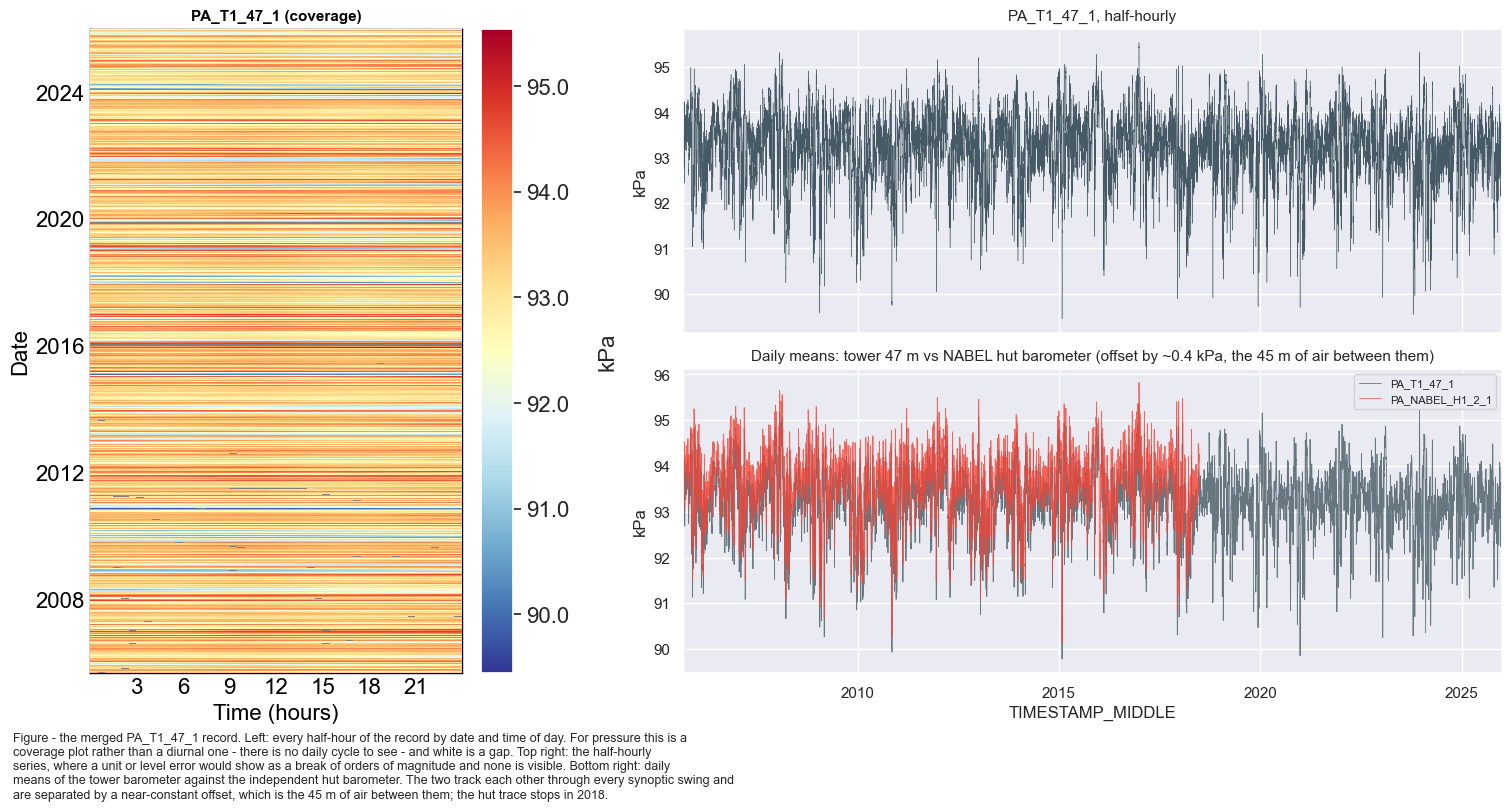

In [14]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_ref = fig.add_subplot(gs[1, 1], sharex=ax_ts)

dv.plotting.HeatmapDateTime(series=pa_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET} (coverage)', title_fontsize=11))

pa_2005_2025[TARGET].plot(ax=ax_ts, lw=0.3, color='#455A64')
ax_ts.set_ylabel('kPa')
ax_ts.set_title(f'{TARGET}, half-hourly', fontsize=11)

pa_2005_2025[[TARGET, REFERENCE]].resample('1D').mean().plot(
    ax=ax_ref, lw=0.6, color=['#455A64', '#F44336'], alpha=.8)
ax_ref.set_ylabel('kPa')
ax_ref.set_title('Daily means: tower 47 m vs NABEL hut barometer '
                 '(offset by ~0.4 kPa, the 45 m of air between them)', fontsize=11)
ax_ref.legend(fontsize=8)
figcap(fig, f"the merged {TARGET} record. Left: every half-hour of the record by date and time of "
            f"day. For pressure this is a coverage plot rather than a diurnal one - there is no "
            f"daily cycle to see - and white is a gap. Top right: the half-hourly series, where a "
            f"unit or level error would show as a break of orders of magnitude and none is "
            f"visible. Bottom right: daily means of the tower barometer against the independent "
            f"hut barometer. The two track each other through every synoptic swing and are "
            f"separated by a near-constant offset, which is the 45 m of air between them; the hut "
            f"trace stops in 2018.")

***

## ✴️ Corrections

### The reference series, and why they make these diagnostics possible

Two independent barometers are available for the corrections, and neither is on the tower logger —
which is exactly what is needed to judge a tower-logger fault.

`PA_NABEL_H1_2_1` sits at the hut, 2 m, on the **NABEL** acquisition system. It runs from 2005 to
the middle of 2018 — the trim above — which includes all of 2012, so it is the reference for the
2012 diagnostics below. The tower sensor reads a near-constant amount lower than the hut sensor,
because it hangs 45 m higher up the tower; that offset is computed from the data here rather than
assumed, and it is checked against the barometric formula in a later section. Subtracting it turns
NABEL into a **predicted tower pressure**, and the residual is then a sensitive fault detector —
over an undisturbed period the two agree to a few hundredths of a kPa.

The hut barometer **stops in 2018**. **MeteoSwiss Lägern** (2.5 km, 845 m) covers the whole
2004-2025 record and is brought in further below as a second independent reference, so the years
after 2018 can be checked too — which the hut barometer alone cannot do.

In [15]:
OFFSET = float((pa_2005_2025[TARGET] - pa_2005_2025[REFERENCE]).median())
reference = pa_2005_2025[REFERENCE] + OFFSET   # NABEL expressed as expected tower pressure

print(f"median(tower - NABEL) = {OFFSET:+.4f} kPa")
print("  the barometric formula is applied to this properly in the sensor section below; "
      "here the offset is only a working constant for the 2012 residual")

_res = (pa_2005_2025[TARGET] - reference).abs()
_quiet = _res.loc['2012-06-01':'2012-07-25']
BASELINE_P999 = float(_quiet.quantile(0.999))
print(f"\nundisturbed agreement (1 Jun - 25 Jul 2012): median {float(_quiet.median()):.4f} kPa, "
      f"p99 {float(_quiet.quantile(0.99)):.4f}, p99.9 {BASELINE_P999:.4f}")
print(f"whole-record median |residual|: {float(_res.median()):.4f} kPa")

median(tower - NABEL) = -0.3990 kPa
  the barometric formula is applied to this properly in the sensor section below; here the offset is only a working constant for the 2012 residual

undisturbed agreement (1 Jun - 25 Jul 2012): median 0.0433 kPa, p99 0.0941, p99.9 0.1370
whole-record median |residual|: 0.0340 kPa


### Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded. `PA_T1_47_1`
is on that logger (tower 1, 47 m, same acquisition system as `SW_IN_T1_47_1` and `TA_T1_47_1`), so
the same `+15.5 h` correction as in notebooks `01`-`03` is applied.

::: {.callout-important title="Why the lag diagnostic works for pressure after all"}
The obvious objection is that the per-day best-alignment lag search used in `01`-`03` relies on a
strong **diurnal** cycle, and pressure has almost none — the semidiurnal tide is ~1-2 hPa against
synoptic swings of tens of hPa. That objection is right about the diurnal cycle and wrong about the
conclusion.

The signal here is **synoptic, not diurnal**. Pressure wanders by 1-3 kPa over a few days and
decorrelates over roughly that timescale, so shifting the series by 15.5 h against an *independent
barometer* produces a large residual. What makes it work is having `PA_NABEL_H1_2_1` as a reference
that is not on the faulty logger; without a second barometer the test would indeed be underpowered.

The numbers below confirm it directly, and the confirmation is not subtle: over an undisturbed week
the two barometers agree to 0.03 kPa, and on the shifted days the zero-lag error is 10-20x that.

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| Jun 2012 (baseline) | 0 | 0.03 | 0.03 |
| 2012-07-27 | -1.0 h | 0.057 | 0.063 |
| 2012-07-29 | +1.0 h | 0.031 | 0.043 |
| 2012-07-30 | +5.0 h | 0.085 | 0.168 |
| 2012-07-31 | +29.0 h | 0.086 | 0.341 |
| 2012-08-06 | -31.5 h | 0.137 | 0.653 |
| 2012-08-07 | -35.5 h | 0.066 | 0.945 |
| **2012-08-11** | **+14.0 h** | **0.026** | 0.324 |
| **2012-08-15** | **+15.5 h** | **0.072** | 0.539 |
| **2012-08-16** | **+15.5 h** | **0.046** | 0.217 |
| 2012-08-18 | (alias) | 0.015 | 0.068 |

(RMSE in kPa, against the NABEL barometer. Lags searched over +/-48 h in 30 min steps.)

- **15-16 August** lock onto exactly `+15.5 h`, the same offset found in `SW_IN` and `TA`. That is
  the logger clock.
- **30 July to 9 August** never recovers at any lag, so it is not a clock problem — see the next
  section.
- Large apparent lags of 24-48 h are aliases: pressure is autocorrelated over days, so shifting by
  about a day partially realigns it. They are ignored.
:::

Notebooks `01`-`03` validate this correction with heatmaps, where the check is that the warm/bright
band returns to midday. **That check does not exist for pressure**, which has no diurnal band to
move. The validation used here instead is the residual against the NABEL barometer, before and
after: if the shift is right, the error collapses to the undisturbed baseline.

In [16]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5

_df = pa_2005_2025.copy()
_before = _df[TARGET].copy()   # kept for the before/after comparison below

# Take the mis-stamped block and move it onto the correct time axis.
_series_shifted = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna()
_series_shifted.index = _series_shifted.index + pd.Timedelta(hours=SHIFT_HOURS)

# Clear everything between the start of the issue and the last shifted timestamp, then write the
# corrected values back. Same procedure as notebooks 01-03.
_df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
_df.loc[_series_shifted.index, TARGET] = _series_shifted

print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")

# Validation: daily RMSE against the NABEL barometer, before vs after.
_rows = []
for _day in pd.date_range('2012-08-09', '2012-08-18', freq='D'):
    _d = _day.strftime('%Y-%m-%d')

    def _rmse(series):
        _x, _y = series.loc[_d], reference.loc[_d]
        _ok = _x.notna() & _y.notna()
        return float(np.sqrt(((_x[_ok] - _y[_ok]) ** 2).mean())) if _ok.sum() >= 12 else np.nan

    _rows.append((_d, _rmse(_before), _rmse(_df[TARGET])))

_check = pd.DataFrame(_rows, columns=['date', 'RMSE_before_kPa', 'RMSE_after_kPa']).set_index('date')
_check['improvement'] = (_check.RMSE_before_kPa - _check.RMSE_after_kPa).round(3)
tabcap("daily root-mean-square difference between the tower barometer and the hut barometer over the affected days, before and after the timestamp shift. Undisturbed, the two agree to about 0.04 kPa, so an 'after' column near that value is the correction landing")
display(_check.round(3))
print("Undisturbed agreement is about 0.04 kPa, so 'after' values near 0.05 kPa mean the "
      "correction landed.")

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00
Table - daily root-mean-square difference between the tower barometer and the hut barometer over the
affected days, before and after the timestamp shift. Undisturbed, the two agree to about 0.04 kPa,
so an 'after' column near that value is the correction landing



,RMSE_before_kPa,RMSE_after_kPa,improvement
date,,,
2012-08-09,0.066,0.080,-0.014
2012-08-10,0.135,0.054,0.081
2012-08-11,0.322,0.047,0.275
2012-08-12,0.092,0.054,0.038
2012-08-13,0.104,0.063,0.041
2012-08-14,0.070,0.067,0.003
2012-08-15,0.540,0.074,0.466
2012-08-16,0.218,0.047,0.171
2012-08-17,0.074,0.062,0.013


Undisturbed agreement is about 0.04 kPa, so 'after' values near 0.05 kPa mean the correction landed.


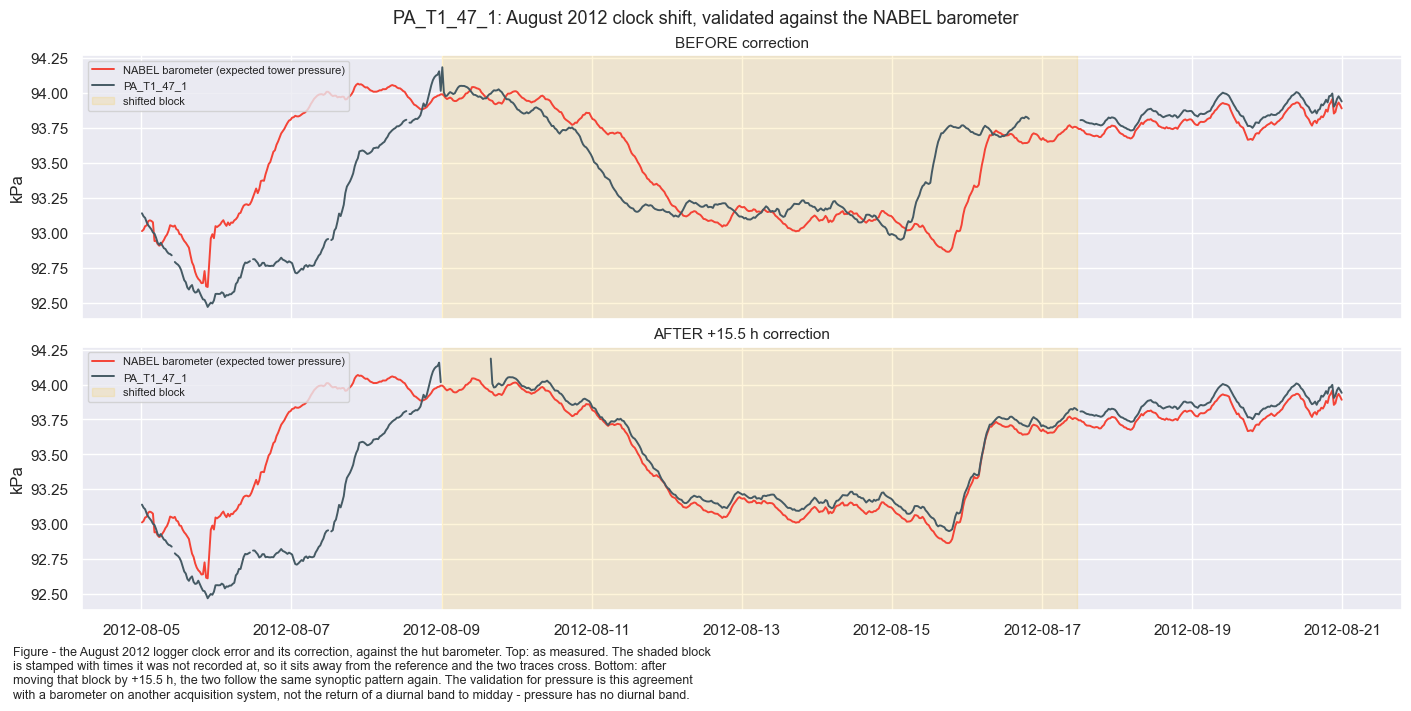

In [17]:
# Visual check: tower vs reference around the shift, before and after.
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift, validated against the NABEL barometer',
             fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

for _ax, _series, _title in [(axs[0], _before, 'BEFORE correction'),
                             (axs[1], _df[TARGET], f'AFTER +{SHIFT_HOURS} h correction')]:
    _ax.plot(reference.loc[_win].index, reference.loc[_win].values,
             color='#F44336', lw=1.4, label='NABEL barometer (expected tower pressure)')
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values,
             color='#455A64', lw=1.4, label=TARGET)
    _ax.axvspan(pd.Timestamp('2012-08-09'), pd.Timestamp('2012-08-17 11:15'),
                color='#FFC107', alpha=.15, label='shifted block')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel('kPa')
    _ax.legend(fontsize=8, loc='upper left')
figcap(fig, f"the August 2012 logger clock error and its correction, against the hut barometer. "
            f"Top: as measured. The shaded block is stamped with times it was not recorded at, so "
            f"it sits away from the reference and the two traces cross. Bottom: after moving that "
            f"block by +{SHIFT_HOURS} h, the two follow the same synoptic pattern again. The "
            f"validation for pressure is this agreement with a barometer on another acquisition "
            f"system, not the return of a diurnal band to midday - pressure has no diurnal band.")

In [18]:
pa_2005_2025 = _df.copy()
pa_2005_2025

,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


### Damaged periods in 2012

Two periods cannot be repaired by a shift, and are removed. They are the same two faults that
notebooks `01`-`03` remove, but **the windows here are derived from `PA`'s own evidence** rather
than copied, and they differ from the shared ones.

The evidence is the residual against the NABEL barometer, on the **corrected** time axis, in
half-day blocks. Undisturbed, |residual| stays near 0.04 kPa (p99.9 = 0.136 kPa over 1 Jun - 25 Jul
2012). Blocks marked `*` exceed that:

| block (corrected axis) | mean abs. residual | verdict |
|---|---|---|
| 2012-07-29 all day | 0.039 / 0.045 | clean |
| 2012-07-30 00:00-12:00 | 0.035 | clean |
| **2012-07-30 12:00-24:00** | **0.177** | * fault begins |
| 2012-07-31 00:00-12:00 | 0.383 | * |
| 2012-08-07 00:00-12:00 | 1.119 | * worst |
| 2012-08-09 12:00-24:00 | 0.065 (max 0.236) | * last bad block |
| **2012-08-10 00:00-12:00** | **0.036** | clean, fault over |
| 2012-10-28, 2012-10-29 | 0.006 - 0.017 | **clean** (best days in the record) |
| **2012-10-30 00:00-12:00** | **0.198** | * second fault begins |
| 2012-11-01 00:00-12:00 | 2.365 | * worst |
| 2012-11-09 00:00-12:00 | 0.115 | * last bad block |
| **2012-11-09 12:00-24:00** | **0.046** | clean, fault over |

The fieldbook gives the causes, and they are the same ones documented at length in notebooks `01`
and `02`:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

`PA` recovers on 10 August, the day after the power supply was replaced, and on 9 November, three
days after the cable work. The fault signature is a **level error** — the sensor keeps reporting a
full 48 records a day, but biased by up to +2.4 kPa — not a dropout and not a phase error, which is
what a mis-powered barometer looks like.

**Where these windows differ from `01`-`03`, and why:**

| | notebooks 01-03 | here | reason |
|---|---|---|---|
| window 1 | 07-29 00:00 -> 08-10 15:30 | 07-30 12:00 -> 08-10 00:00 | `PA` is still clean through 30 July midday |
| window 2 | 08-17 15:30 -> 08-18 00:00 | *(none)* | `PA` is clean on 17-18 Aug (0.04-0.08 kPa) |
| window 3 | 10-28 00:00 -> 11-10 00:00 | 10-30 00:00 -> 11-09 12:00 | 28-29 Oct are `PA`'s two **best** days |

Notebook `02` widened `TA`'s third window to 28 October to match `SW_IN` and the shared cause,
knowingly discarding one good day. That trade is not made here: with 969 records removed instead of
1,209, `PA` keeps 240 half-hours (5 days) of measurements that its own independent reference shows
to be sound. Because this product is not gap-filled, a removed record is a permanent hole rather
than a modelled value, which makes the case for keeping demonstrably good data stronger.

**Consequence to be aware of:** the four METEO products no longer exclude byte-identical periods.
Anything downstream that assumes they do should use each product's own missingness.

In [19]:
# Derived from PA's own residual against the NABEL barometer (see the table above), NOT copied
# from notebooks 01-03. Windows are on the CORRECTED time axis, i.e. after the +15.5 h shift.
BAD_WINDOWS_2012 = [
    ('2012-07-30 12:00', '2012-08-10 00:00'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-10-30 00:00', '2012-11-09 12:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_before_n = int(pa_2005_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    pa_2005_2025.loc[_start:_end, TARGET] = np.nan
_removed = _before_n - int(pa_2005_2025[TARGET].notna().sum())
print(f"Removed {_removed:,} degraded records from {TARGET} (left as gaps, nothing is filled).")

# Verify: nothing above the undisturbed baseline should survive in 2012.
_res_2012 = (pa_2005_2025[TARGET] - reference).abs().loc['2012'].dropna()
_exceed = _res_2012[_res_2012 > BASELINE_P999]
print(f"\n2012 after removal: median |residual| {float(_res_2012.median()):.4f} kPa, "
      f"max {float(_res_2012.max()):.4f} kPa")
print(f"records still above the undisturbed p99.9 ({BASELINE_P999:.4f} kPa): {len(_exceed)}")
if len(_exceed):
    tabcap("the records that still depart from the hut barometer by more than the undisturbed p99.9 after the two 2012 windows are removed, by day")
    display(_exceed.groupby(_exceed.index.normalize()).agg(['count', 'max']))
    print("(a handful of isolated records in undisturbed months is ordinary tail noise, "
          "not a missed fault period)")

Removed 969 degraded records from PA_T1_47_1 (left as gaps, nothing is filled).

2012 after removal: median |residual| 0.0334 kPa, max 0.1777 kPa
records still above the undisturbed p99.9 (0.1370 kPa): 3
Table - the records that still depart from the hut barometer by more than the undisturbed p99.9
after the two 2012 windows are removed, by day



,count,max
TIMESTAMP_MIDDLE,,
2012-06-07,1,0.140061
2012-06-21,1,0.177674
2012-06-30,1,0.175678


(a handful of isolated records in undisturbed months is ordinary tail noise, not a missed fault period)


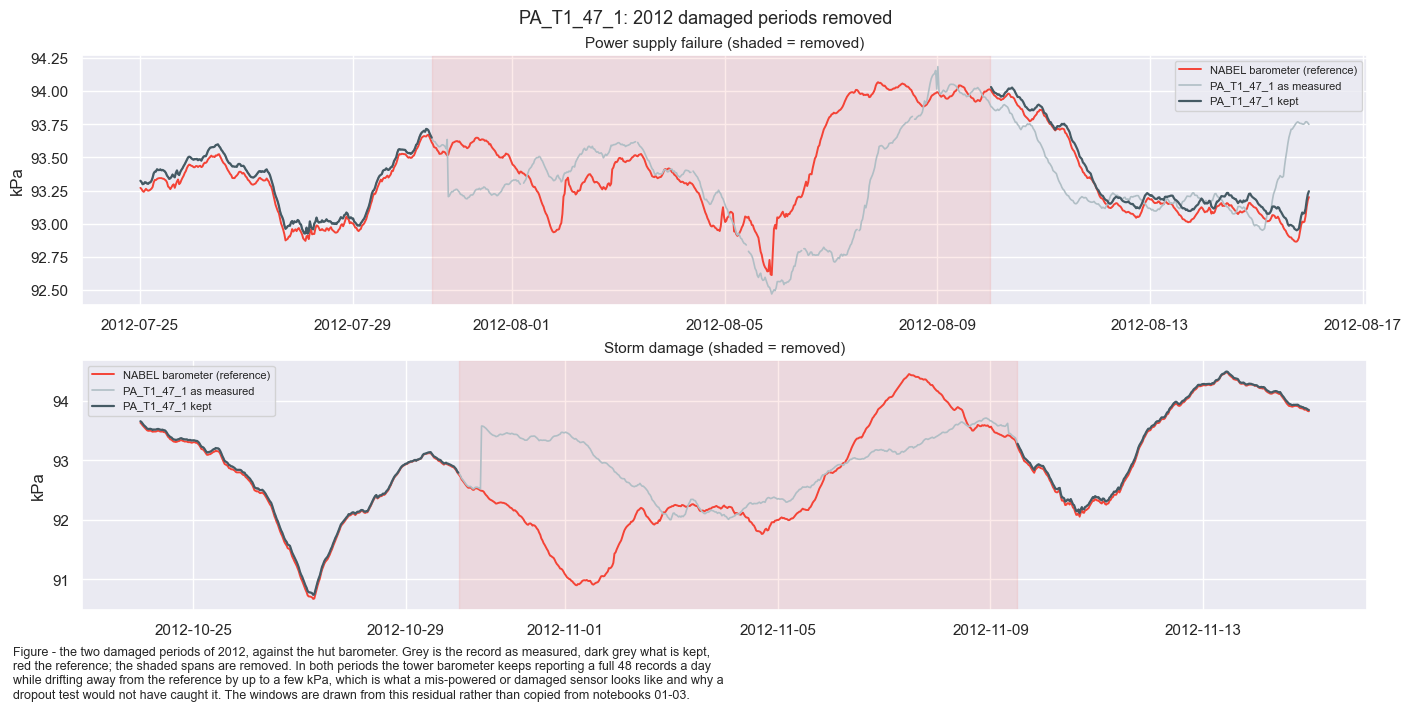

In [20]:
# The two fault periods, before/after, against the reference.
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 damaged periods removed', fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-15', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(reference.loc[_w].index, reference.loc[_w].values,
             color='#F44336', lw=1.4, label='NABEL barometer (reference)')
    _ax.plot(_before.loc[_w].index, _before.loc[_w].values,
             color='#B0BEC5', lw=1.2, label=f'{TARGET} as measured')
    _ax.plot(pa_2005_2025[TARGET].loc[_w].index, pa_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel('kPa')
    _ax.legend(fontsize=8, loc='best')
figcap(fig, f"the two damaged periods of 2012, against the hut barometer. Grey is the record as "
            f"measured, dark grey what is kept, red the reference; the shaded spans are removed. "
            f"In both periods the tower barometer keeps reporting a full 48 records a day while "
            f"drifting away from the reference by up to a few kPa, which is what a mis-powered or "
            f"damaged sensor looks like and why a dropout test would not have caught it. The "
            f"windows are drawn from this residual rather than copied from notebooks 01-03.")

::: {.callout-note title="No zero-offset correction here"}
Notebooks `01` and `03` remove a nighttime zero-offset from `SW_IN` and `PPFD_IN`. That correction
exists because radiation has a known true value at night, namely zero, so any nonzero nighttime
reading is measurable sensor offset. Pressure has no such reference value at any time of day, so
there is no equivalent step and none is applied.

The related trap from notebook `03` — a correction that writes into gaps and thereby relabels fills
as measurements — **cannot occur in this notebook**: no correction here writes a value into a
missing record. The clock shift moves existing records, and the 2012 windows only ever set values to
`NaN`. Gap counts are therefore honest at every stage, which the export checks below confirm.
:::

### 🌍 MeteoSwiss Lägern: an independent check across the whole record

The NABEL barometer used above **stops in 2018**, so on its own it cannot confirm the second half of
the record. MeteoSwiss Lägern (2.5 km away at 845 m) measures station pressure over the full
2004-2025 span and closes that gap.

Pressure is strongly spatially coherent: once a constant altitude offset is removed, the tower and
Lägern correlate ~0.99. Lägern is stored in `hPa`, so it is divided by 10 to `kPa`. It sits about 110 m
above the tower barometer and therefore reads a near-constant amount **lower**; that offset
is **fitted from the overlap** (mean of `tower - Lägern` where both are present), not assumed, and
added to Lägern so the two are directly comparable.

Like NABEL, Lägern is a **diagnostic reference only** — never exported, and it never changes a tower
value. Two checks follow: the alignment guard (as in notebooks `01`-`03`) proves the
`TIMESTAMP_END -> TIMESTAMP_MID` conversion, and the residual before and after 2018 shows the tower
and Lägern stay in agreement, i.e. no shift or fault slipped through after NABEL ended.

In [21]:
# Pressure, and also the temperature and vapour pressure of the air column, which the
# barometric check below needs. All three come from the same station and the same file.
_lae = pd.read_parquet(REFPATH)[[REFCOL, REFCOL_TA, REFCOL_VP]].copy()
_lae.index = _lae.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
_lae.index.name = pa_2005_2025.index.name
_lae = _lae.reindex(pa_2005_2025.index)
pa_lae = _lae[REFCOL] / 10.0   # hPa -> kPa, onto the product index
ta_lae = _lae[REFCOL_TA]       # deg C
vp_lae = _lae[REFCOL_VP]       # hPa

# Hydrostatic offset, fitted from the overlap rather than guessed: Laegern (845 m) reads lower than
# the tower barometer (~690 m). Add it to Laegern so both sit on the tower's pressure level.
_both = pd.concat([pa_2005_2025[TARGET].rename('tower'), pa_lae.rename('lae')],
                  axis=1, sort=False).dropna()
LAE_OFFSET = float((_both['tower'] - _both['lae']).mean())
lae_adjusted = pa_lae + LAE_OFFSET
print(f"fitted tower - Laegern offset: {LAE_OFFSET:+.4f} kPa "
      f"(mean over {len(_both):,} overlapping records; Laegern reads lower, sitting higher)")

# Alignment guard (as in notebooks 01-03): correlate the measured tower PA against Laegern-adjusted
# at -1/0/+1 half-hour offsets. Offset 0 must win, which proves the TIMESTAMP_MID conversion.
# Pressure is spatially coherent, so the correlation is ~0.99 and the zero-lag peak is clear.
_meas = pa_2005_2025[TARGET]
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), lae_adjusted.shift(_off).rename('r')],
                   axis=1, sort=False).dropna()
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.5f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

fitted tower - Laegern offset: +1.2798 kPa (mean over 352,075 overlapping records; Laegern reads lower, sitting higher)
  offset -1 x 30min: corr 0.99033
  offset +0 x 30min: corr 0.99063
  offset +1 x 30min: corr 0.99018
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.


  while the hut barometer runs     median +0.0712  std 0.0717 kPa  n=221,532
  Laegern the only witness         median -0.1058  std 0.0431 kPa  n=130,544
The scatter is what this check is about, and it is tight in both halves: no timestamp error and no fault went undetected after the hut barometer stopped.
The LEVELS of the two halves differ by 0.177 kPa, which is not scatter. That is the January 2016 step and the slow drift, and the next section takes both of them up.


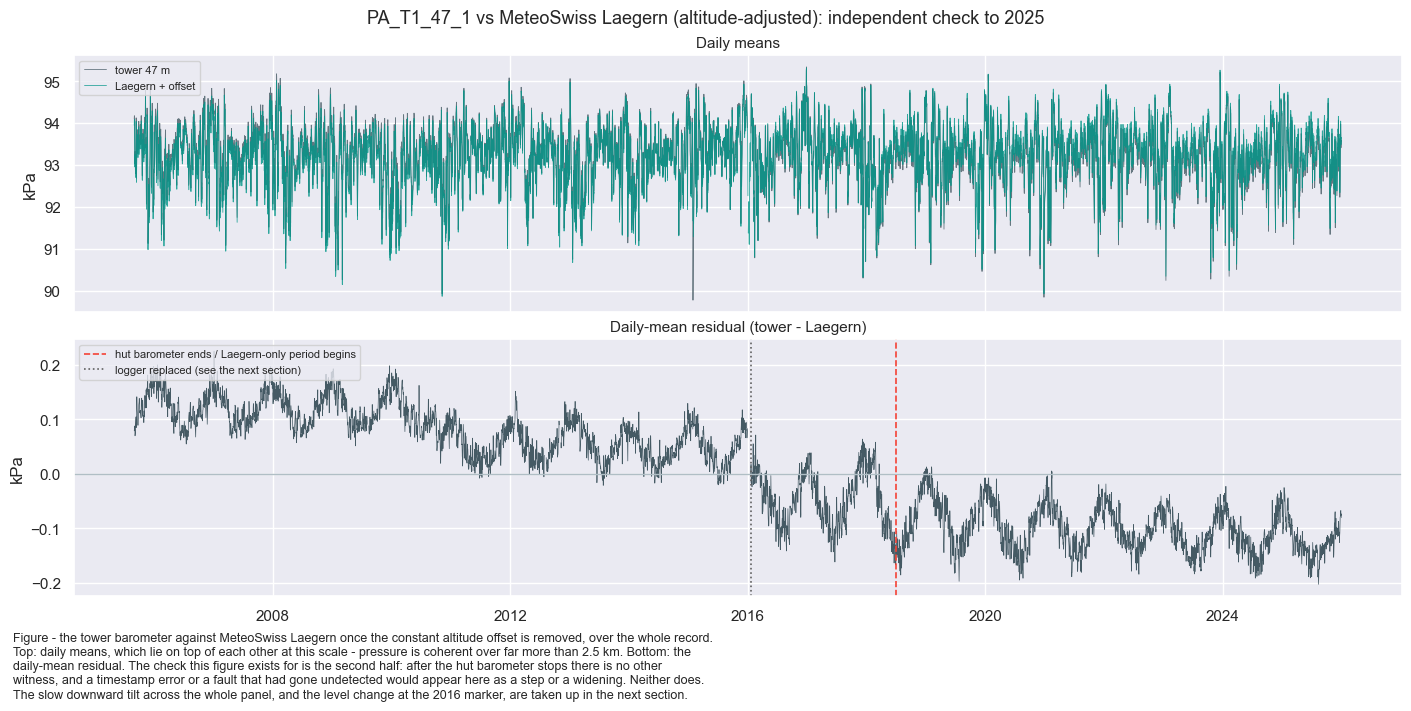

In [22]:
# The post-2018 payoff: NABEL has stopped, Laegern has not. If a timestamp shift or a level fault
# had gone undetected after 2018, the tower - Laegern residual would step or widen there. It does not.
_res_lae = (pa_2005_2025[TARGET] - lae_adjusted)
_split = pa_2005_2025[REFERENCE].last_valid_index()
for _lbl, _sl in [('while the hut barometer runs', slice(None, _split)),
                  ('Laegern the only witness', slice(_split, None))]:
    _r = _res_lae.loc[_sl].dropna()
    print(f"  {_lbl:<32} median {float(_r.median()):+.4f}  std {float(_r.std()):.4f} kPa  n={len(_r):,}")
print("The scatter is what this check is about, and it is tight in both halves: no timestamp "
      "error and no fault went undetected after the hut barometer stopped.")
print("The LEVELS of the two halves differ by "
      f"{abs(float(_res_lae.loc[:_split].median() - _res_lae.loc[_split:].median())):.3f} kPa, "
      "which is not scatter. That is the January 2016 step and the slow drift, and the next "
      "section takes both of them up.")

fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained', sharex=True)
fig.suptitle(f'{TARGET} vs MeteoSwiss Laegern (altitude-adjusted): independent check to 2025',
             fontsize=13)
_daily = pd.DataFrame({'tower': pa_2005_2025[TARGET], 'lae': lae_adjusted}).resample('1D').mean()
axs[0].plot(_daily.index, _daily['tower'].values, lw=0.6, color='#455A64', alpha=.8, label='tower 47 m')
axs[0].plot(_daily.index, _daily['lae'].values, lw=0.6, color='#009688', alpha=.8, label='Laegern + offset')
axs[0].set_ylabel('kPa')
axs[0].set_title('Daily means', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')

_res_daily = _res_lae.resample('1D').mean()
axs[1].plot(_res_daily.index, _res_daily.values, lw=0.5, color='#455A64')
axs[1].axhline(0, color='#B0BEC5', lw=1)
axs[1].axvline(pa_2005_2025[REFERENCE].last_valid_index(), color='#F44336', ls='--', lw=1.2,
               label='hut barometer ends / Laegern-only period begins')
axs[1].axvline(pd.Timestamp(ACQUISITION_CHANGE), color='#616161', ls=':', lw=1.2,
               label='logger replaced (see the next section)')
axs[1].set_ylabel('kPa')
axs[1].set_title('Daily-mean residual (tower - Laegern)', fontsize=11)
axs[1].legend(fontsize=8, loc='upper left')
figcap(fig, f"the tower barometer against MeteoSwiss Laegern once the constant altitude offset is "
            f"removed, over the whole record. Top: daily means, which lie on top of each other at "
            f"this scale - pressure is coherent over far more than 2.5 km. Bottom: the daily-mean "
            f"residual. The check this figure exists for is the second half: after the hut "
            f"barometer stops there is no other witness, and a timestamp error or a fault that had "
            f"gone undetected would appear here as a step or a widening. Neither does. The slow "
            f"downward tilt across the whole panel, and the level change at the 2016 marker, are "
            f"taken up in the next section.")

***

## 🔎 Which sensor this is, and what the hardware changes did to it

`PA_T1_47_1` is the name of a variable, not of an instrument, and at this site several variables
reuse one name across sensor generations. This section asks what hardware stands behind the name,
what the two boundaries in the record did to it, and whether the absolute level of the series is
right. Pressure is the one meteorological variable here whose absolute level can be checked against
physics rather than only against another sensor, and that check is used.

What the section establishes:

1. **one barometer and one conversion over the whole record** — a Vaisala PTB101B read at
   multiplier `0.184` and offset `600`, identical in all seven surviving logger programs;
2. **the record begins long after the last change to this channel**, so no part of it belongs to a
   different sensor or a different conversion;
3. **the absolute level agrees with the barometric formula** — the measured difference against a
   station 2.5 km away and about 110 m above the barometer is predicted, without a fitted
   parameter, to within a few hundredths of a kPa, and the seasonal shape of that difference is
   predicted too;
4. **three barometers give three pairwise differences**, and the pattern of which ones move names
   the instrument that changed;
5. **the tower barometer steps at the January 2016 acquisition change**, by about 0.09 kPa. This is
   a positive result, not a negative one, and it is the reason for the callout at the top of this
   notebook;
6. **nothing steps at the December 2021 screening splice**;
7. **the maintenance record has never once named this barometer** in twenty-one years.

### Helpers for this section

The logger programs and the maintenance record are read in the notebook rather than quoted, so that
a re-run re-derives the argument instead of inheriting a stale copy of it. Both are signed by the
people who did the work and this notebook renders to a public page, so every string taken out of
either passes through the same redaction used in notebooks `01`, `02`, `03` and `08`.

In [23]:
# --- Fieldbook and logger-program redaction ----------------------------------------------------
# The GIN export and the logger programs both name people. This notebook renders to a public page,
# so every string taken out of either passes through redact_people() at the single point where it
# is flattened. Same map and same rules as notebooks 01, 02, 03 and 08; the map lives beside the
# export, OUTSIDE this repository, so the repo never carries a real name.
REDACT_MAP = Path(FIELDBOOK).with_name('redact_names.csv')
ALLOW_LIST = Path(FIELDBOOK).with_name('redact_allow.csv')


def unmapped_report_path(label: str) -> Path:
    """Where the unmapped-name candidates of one audit are written.

    Per label, because this notebook audits two sources: a single shared file would let the
    second audit overwrite the first one's findings.
    """
    _slug = re.sub(r'[^a-z0-9]+', '_', label.lower()).strip('_')
    return Path(FIELDBOOK).with_name(f'redact_unmapped_{_slug}.txt')


def load_redactions(path=None) -> dict:
    """Load the name -> pseudonym map.

    Raises if the map is missing. That is the point: carrying on with redaction quietly disabled
    prints real names into a published page and looks exactly like success.
    """
    path = REDACT_MAP if path is None else Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"the redaction map is missing: {path}. Without it the names these files record would "
            f"print unredacted. Restore the file rather than skipping this.")
    tab = pd.read_csv(path, encoding='utf-8')
    missing = {'name', 'pseudonym'}.difference(tab.columns)
    if missing:
        raise ValueError(f"{path}: missing column(s) {sorted(missing)}.")
    pairs = {str(n).strip(): str(p).strip()
             for n, p in zip(tab['name'], tab['pseudonym']) if str(n).strip()}
    if not pairs:
        raise ValueError(f"{path}: holds no usable name -> pseudonym pairs.")
    return pairs


REDACTIONS = load_redactions()
# Longest surface form first, so a bare surname cannot corrupt a double-barrelled one that starts
# with it. Lookarounds rather than \b, because some forms end in an initial.
_REDACT_RX = re.compile(r'(?<!\w)(' + '|'.join(re.escape(n) for n in
                                               sorted(REDACTIONS, key=len, reverse=True))
                        + r')(?!\w)')


def redact_people(s) -> str:
    """Replace every mapped name with its stable pseudonym."""
    return _REDACT_RX.sub(lambda m: REDACTIONS[m.group(1)], str(s))


def strip_html(text) -> str:
    """Flatten one GIN fieldbook entry to plain text, with the people it names redacted."""
    flat = html.unescape(re.sub(r'<[^>]+>', ' ', str(text)))
    return redact_people(re.sub(r'\s+', ' ', flat).strip())


_NAME_TOKEN = r"[A-ZÄÖÜ][\wÄÖÜäöüß'-]{1,20}"
_NAME_UNIT = _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r'){0,2}'
_NAME_SHAPES = (
    re.compile(r'\((' + _NAME_UNIT + r'(?:\s*[,+&]\s*' + _NAME_UNIT + r')*)\s*'
               r'(?:\d{1,2}\.\d{1,2}\.\d{4})?\)'),
    re.compile(r'(?:with|by|durch|von|gemaess)\s+(' + _NAME_TOKEN + r'(?:\s+' + _NAME_TOKEN + r')?)'),
)


def audit_unmapped_names(texts, label='fieldbook', write_report: bool = True) -> int:
    """Raise if any name-shaped token survived redaction.

    A newer export can name someone the map has never seen. Candidates are never printed - an
    exception message is stored in a notebook like any other output - so they go to a file beside
    the map and only the count is shown.
    """
    allow = set(pd.read_csv(ALLOW_LIST, encoding='utf-8')['term'].astype(str).str.strip())
    found = {}
    for _t in texts:
        for _rx in _NAME_SHAPES:
            for _m in _rx.finditer(str(_t)):
                for _tok in re.findall(_NAME_TOKEN, _m.group(1)):
                    if _tok.isupper() or any(ch.isdigit() for ch in _tok) or _tok in allow:
                        continue
                    found[_tok] = found.get(_tok, 0) + 1
    if found:
        _report = unmapped_report_path(label)
        if write_report:
            _report.write_text(
                '\n'.join(f'{n}\t{t}' for t, n in sorted(found.items(), key=lambda kv: -kv[1])),
                encoding='utf-8')
        raise ValueError(
            f"{label}: {len(found)} name-shaped token(s) survived redaction. They are deliberately "
            f"NOT shown here - see {_report}. Add the people to redact_names.csv and the "
            f"technical terms to redact_allow.csv, then re-run.")
    print(f"  {label}: no unmapped name-shaped tokens ({len(allow)} allowlisted terms)")
    return 0


def program_excerpt(path, pattern: str, before: int = 6, after: int = 4, expect: int = 1) -> str:
    """The lines of a logger program around `pattern`, redacted.

    Only the matched instruction is returned, never the file header: these programs are signed by
    their authors. Raises unless the pattern matches exactly `expect` times. Both directions
    matter: no match reads as 'the program does not measure this', and an over-broad pattern
    quietly prints the wrong instruction next to the argument it is supposed to support.
    """
    lines = Path(path).read_text(encoding='latin-1').splitlines()
    blocks = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            lo, hi = max(0, i - before), min(len(lines), i + after + 1)
            blocks.append('\n'.join(lines[lo:hi]))
    if len(blocks) != expect:
        raise ValueError(f"{Path(path).name}: {pattern!r} matched {len(blocks)} time(s), expected "
                         f"{expect}. The program layout has changed, the wrong file is configured, "
                         f"or the pattern is not specific enough.")
    return redact_people('\n\n'.join(blocks))


def uncommented(excerpt: str) -> str:
    """Drop the comment part of every line of a logger-program excerpt.

    Notebook 03 did not need this and this notebook does. Both program languages keep dead code in
    comments, and the CR1000 keeps some here: two lines above the live pressure instruction sits a
    commented-out single-ended version of it, carrying a DIFFERENT multiplier. A parser reading the
    raw excerpt finds that one first and reports constants the logger has never applied. CR10X
    comments begin with `;`, CRBasic comments with `'`.
    """
    out = []
    for line in excerpt.splitlines():
        stripped = re.split(r"[;']", line, maxsplit=1)[0].rstrip()
        if stripped.strip():
            out.append(stripped)
    return '\n'.join(out)


def calibration_constants(excerpt: str, consts: dict | None = None) -> dict:
    """The multiplier and offset of one measurement instruction, parsed from its own text.

    Two shapes occur across the two program languages and both are matched on their own terms: the
    CR10X lists the two numbers as numbered parameters, while the CR1000 passes them as the last
    two arguments of a `VoltSe(...)` or `VoltDiff(...)` call. Copied from notebook 03, including
    the `consts` path, which this variable does not use - the CR1000 writes its pressure constants
    as literals.

    Raises if either number cannot be found. A silently empty result would make the comparison
    below pass by having nothing to disagree about.
    """
    if 'Mult' in excerpt:                                    # CR10X parameter listing
        _m = re.search(r'^\s*\d+:\s*([\d.]+)\s+Mult', excerpt, re.M)
        _o = re.search(r'^\s*\d+:\s*([\d.]+)\s+Offset', excerpt, re.M)
        tokens = [_m.group(1) if _m else None, _o.group(1) if _o else None]
    else:                                                    # CR1000 VoltSe/VoltDiff call
        _call = re.search(r'Volt(?:Se|Diff)\s*\(([^)]*)\)', excerpt)
        _args = [a.strip() for a in _call.group(1).split(',')] if _call else []
        tokens = _args[-2:] if len(_args) >= 2 else [None, None]

    values = []
    for _tok in tokens:
        if _tok is None:
            raise ValueError("could not parse a multiplier and an offset from the instruction - "
                             "the program language or the layout has changed")
        try:
            values.append(float(_tok))
        except ValueError:
            if not consts or _tok not in consts:
                raise ValueError(
                    f"the instruction gives its constant as the name {_tok!r}, which is not among "
                    f"the declarations passed in.")
            values.append(consts[_tok])
    return {'multiplier': values[0], 'offset': values[1]}

In [24]:
# The guards guard. A helper that silently returns nothing is worse than no helper, so every
# failure path is exercised before anything is read.
try:
    program_excerpt(PROGRAM_AFTER, r'ThisPatternIsNotInAnyLoggerProgram')
except ValueError as _exc:
    print(f"OK, program_excerpt raised on a pattern that does not occur: {_exc}")
else:
    raise AssertionError("(!) program_excerpt accepted a pattern that does not occur.")

# 'Ada Lovelace' is nobody at this site, so the control can spell her out without disclosing
# anything - and it writes no report, so the real one is not overwritten by a test.
try:
    audit_unmapped_names(['12.05.2019 (Ada Lovelace) replaced the logger battery'],
                         'positive control', write_report=False)
except ValueError:
    print("OK, the unknown-name net fired on a name that is not in the map")
else:
    raise AssertionError("(!) the unknown-name net did not fire on an unmapped name.")

# The constant parser must refuse an instruction it cannot read at all.
try:
    calibration_constants("18:  Volt (Diff) (P2) ;Messung von Kin\n 1: 1        Reps")
except ValueError as _exc:
    print(f"OK, calibration_constants raised on an instruction with no constants: {_exc}")
else:
    raise AssertionError("(!) calibration_constants accepted an instruction carrying no constants.")

# And the comment stripper must actually remove something here, or the constants reported below
# would be the ones in the dead line rather than the ones the logger applies.
_probe = "    'VoltSe (X,1,mV2500,13,1,0,_50Hz,0.1,0)\n    VoltDiff (X,1,mV2500,7,True,0,_50Hz,0.184,600)"
assert calibration_constants(_probe) != calibration_constants(uncommented(_probe)), \
    "(!) the comment stripper changes nothing, so a commented-out instruction could be reported"
print(f"OK, uncommented() changes the answer: raw {calibration_constants(_probe)} -> "
      f"live {calibration_constants(uncommented(_probe))}")

OK, program_excerpt raised on a pattern that does not occur: CH-LAE_iDL_T1_47_1.CR1: 'ThisPatternIsNotInAnyLoggerProgram' matched 0 time(s), expected 1. The program layout has changed, the wrong file is configured, or the pattern is not specific enough.
OK, the unknown-name net fired on a name that is not in the map
OK, calibration_constants raised on an instruction with no constants: could not parse a multiplier and an offset from the instruction - the program language or the layout has changed
OK, uncommented() changes the answer: raw {'multiplier': 0.1, 'offset': 0.0} -> live {'multiplier': 0.184, 'offset': 600.0}


### 1️⃣ One barometer, one conversion, seven programs

The CR1000 program names the instrument in a comment and converts its signal on the next line. The
six CR10X programs of 2004-2006 measure the same sensor into storage location 40 with the same two
numbers, written in the other program language. All seven are parsed rather than one of them read
off, and the notebook asserts they agree — if the multiplier had changed at the 2016 changeover,
the series would step there by construction and the evidence below would be measuring that instead
of the instrument.

In [25]:
# The CR1000 instruction. The excerpt deliberately shows the two comment lines above it: the
# first names the instrument, the second is a commented-out single-ended version of the same
# measurement at a different multiplier, which is why uncommented() exists.
_ex_cr1000 = program_excerpt(PROGRAM_AFTER, r'Vaisala PTB101B', before=0, after=3)
print(_ex_cr1000)

CONSTANTS = {Path(PROGRAM_AFTER).name: calibration_constants(uncommented(_ex_cr1000))}
_cr10x_excerpts = []
for _p in PROGRAMS_CR10X:
    _ex = program_excerpt(_p, r'^; Pressure sensor', before=0, after=13)
    _cr10x_excerpts.append(_ex)
    CONSTANTS[Path(_p).name] = calibration_constants(uncommented(_ex))

print(f"\n--- {Path(PROGRAMS_CR10X[0]).name}, the oldest surviving program")
print(_cr10x_excerpts[0])
audit_unmapped_names(_cr10x_excerpts + [_ex_cr1000], 'logger programs')

tabcap("the conversion every surviving logger program applies to the tower pressure channel, "
       "oldest first. The two program languages write the same two numbers differently and each "
       "shape is matched on its own terms. What changes at the 2016 changeover is the measurement "
       "mode and the unit the result is stored in, not the calibration")
_prog = pd.DataFrame(CONSTANTS).T.reindex(
    [Path(_p).name for _p in PROGRAMS_CR10X] + [Path(PROGRAM_AFTER).name])
_prog.index.name = 'logger program'
_prog['logger'] = ['CR10X'] * len(PROGRAMS_CR10X) + ['CR1000']
_prog['measurement'] = (['Excite-Delay (SE), 2500 mV excitation'] * len(PROGRAMS_CR10X)
                        + ['VoltDiff, differential'])
_prog['stored as'] = ['hPa'] * len(PROGRAMS_CR10X) + ['Pa (x100 on the following line)']
display(_prog)

# One conversion across every program that measures this sensor, CR10X and CR1000 alike.
_mults = {v['multiplier'] for v in CONSTANTS.values()}
_offsets = {v['offset'] for v in CONSTANTS.values()}
print(f"\ndistinct multipliers over the {len(CONSTANTS)} programs: {sorted(_mults)}")
print(f"distinct offsets: {sorted(_offsets)}")
assert _mults == {0.184} and _offsets == {600.0}, (
    "the programs no longer all apply the same conversion to the pressure channel - the argument "
    "that the 2016 changeover cannot have rescaled this series no longer holds")

# The two numbers are not arbitrary: they are the sensor's own range written as a straight line
# over the logger's 2500 mV input, which is what identifies the instrument.
MULTIPLIER, OFFSET_HPA = sorted(_mults)[0], sorted(_offsets)[0]
_span = (OFFSET_HPA, MULTIPLIER * 2500 + OFFSET_HPA)
print(f"conversion span: {_span[0]:.0f} .. {_span[1]:.0f} hPa over 0 .. 2500 mV")
assert _span == (600.0, 1060.0), (
    "the conversion no longer spans 600-1060 hPa, which is the range of the barometer the CR1000 "
    "program names - the identification of the instrument must be re-derived")
print("This is the range of the Vaisala PTB101B the CR1000 program names, so the same barometer "
      "stands behind both acquisition systems.")

    'Vaisala PTB101B barometric sensor
    'VoltSe (PA_T1_47_1,1,mV2500,13,1,0,_50Hz,0.1,0)
    VoltDiff (PA_T1_47_1,1,mV2500,7,True,0,_50Hz,0.184,600)
    PA_T1_47_1 = PA_T1_47_1 * 100 'pressure in Pa

--- LAEGEREN.20040526.CSI, the oldest surviving program
; Pressure sensor
;----------------


3:  Excite-Delay (SE) (P4)
 1: 1        Reps
 2: 05       2500 mV Slow Range
 3: 1        SE Channel
 4: 1        Excite all reps w/Exchan 1
 5: 100      Delay (0.01 sec units)
 6: 2500     mV Excitation
 7: 40       Loc [ Pressure  ]
 8: 0.184    Mult
 9: 600      Offset
  logger programs: no unmapped name-shaped tokens (58 allowlisted terms)
Table - the conversion every surviving logger program applies to the tower pressure channel, oldest
first. The two program languages write the same two numbers differently and each shape is matched on
its own terms. What changes at the 2016 changeover is the measurement mode and the unit the result
is stored in, not the calibration



,multiplier,offset,logger,measurement,stored as
logger program,,,,,
LAEGEREN.20040526.CSI,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
LAEGEREN.20040810.CSI,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
LAEGEREN.20041228.CSI,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
LAEGEREN.20050818.CSI,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
LAEGEREN.20050914.CSI,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
LAEGEREN.20060524.csi,0.184,600.0,CR10X,"Excite-Delay (SE), 2500 mV excitation",hPa
CH-LAE_iDL_T1_47_1.CR1,0.184,600.0,CR1000,"VoltDiff, differential",Pa (x100 on the following line)



distinct multipliers over the 7 programs: [0.184]
distinct offsets: [600.0]
conversion span: 600 .. 1060 hPa over 0 .. 2500 mV
This is the range of the Vaisala PTB101B the CR1000 program names, so the same barometer stands behind both acquisition systems.


The 2016 changeover did change two things about how the signal is read, and neither of
them is the calibration. The CR10X excited the sensor and measured it **single-ended**; the CR1000
measures it **differentially**. And the CR1000 multiplies the result by 100 on the following line,
which is why the two data versions arrive in different units — the unit break this notebook
harmonises at the top is a property of the logger program, not of the database.

A single-ended measurement carries whatever offset sits between the sensor's ground and the
logger's; a differential measurement does not. That is a mechanism by which the level could move at
the changeover without the calibration changing, and step 5️⃣ finds that it did.

### 2️⃣ The record begins long after the last change to this channel

The header of every CR10X program carries the same one-line history, and the last entry in it that
concerns pressure is dated **31 March 2004**. The exported record begins in September 2005, so no
part of it predates that change; unlike `PPFD_IN`, whose storage location held a different probe
until August 2004, this column has never held anything else.

In [26]:
# The dated history line, taken from the programs rather than quoted. before=0/after=0 returns
# the single line, so nothing of the signed header comes with it.
_hist = {Path(_p).name: program_excerpt(_p, r'changed pressure variable to high resolution',
                                        before=0, after=0).strip().lstrip('; ')
         for _p in PROGRAMS_CR10X}
assert len(set(_hist.values())) == 1, "the programs no longer agree on the pressure history line"
CHANNEL_CHANGE = pd.Timestamp(re.match(r'(\d{2})\.(\d{2})\.(\d{4})',
                                       next(iter(_hist.values()))).expand(r'\3-\2-\1'))
print(f"history line, identical in all {len(_hist)} CR10X programs:")
print(f"  {next(iter(_hist.values()))}")

FIRST_MEASURED = pa_2005_2025[TARGET].first_valid_index()
print(f"\nlast change to the pressure channel: {CHANNEL_CHANGE:%d %b %Y}")
print(f"first measured {TARGET} record:      {FIRST_MEASURED:%d %b %Y %H:%M}")
print(f"difference: {(FIRST_MEASURED.normalize() - CHANNEL_CHANGE).days:,} days")
assert FIRST_MEASURED > CHANNEL_CHANGE, (
    "the record now begins before the last change to this channel, so its earliest values were "
    "converted differently and the column spans two conversions")
print("\nThe record starts where the archive starts, not where the sensor starts: the barometer "
      "was already being logged when the oldest surviving program was written in May 2004.")

history line, identical in all 6 CR10X programs:
  31.03.2004 changed pressure variable to high resolution

last change to the pressure channel: 31 Mar 2004
first measured PA_T1_47_1 record:      02 Sep 2005 10:15
difference: 520 days

The record starts where the archive starts, not where the sensor starts: the barometer was already being logged when the oldest surviving program was written in May 2004.


### 3️⃣ The absolute level, against the barometric formula

Every other check in this stage is relative: it can say that two sensors moved apart, not that
either of them is right. Pressure is the exception. It falls with height by a law with no free
parameter, so a barometer's own elevation can be read back out of its readings, and comparing that
with where the instrument actually hangs is an **absolute** test of the level. A unit error, a
wrong offset or a lost factor of ten fails it by orders of magnitude.

The scale height is built from the **virtual** temperature of the air column — humid air is
lighter, and ignoring that makes the predicted difference too large — using the temperature and
vapour pressure MeteoSwiss measures at Lägern, with the layer mean taken half a lapse rate below
the station.

Two things are asked of it. The level: where does each reference put this barometer? And the
shape: the difference between two barometers at different heights has a seasonal cycle, because the
scale height is proportional to temperature, and a formula that gets the mean right by accident
will not also get the cycle right.

In [27]:
# Constants of the hypsometric equation. None of them is fitted.
G_ACCEL = 9.80665     # m s-2
R_DRY = 287.05        # J kg-1 K-1, specific gas constant of dry air
LAPSE_RATE = 0.0065   # K m-1, standard atmosphere; used only to put the layer mean temperature
                      # between the two sensors rather than at the upper one
NOMINAL_ELEVATION = SITE_BASE_ELEVATION + SENSOR_HEIGHT
KPA_PER_METRE = 93.3 / (R_DRY * 283.0 / G_ACCEL)   # for reporting a pressure as metres of air


def scale_height(t_degc, vp_hpa, p_kpa, dz):
    """Scale height R*Tv/g of the layer, from the reference station's own temperature and humidity."""
    t_layer = t_degc + 273.15 + LAPSE_RATE * dz / 2
    return R_DRY * (t_layer / (1 - 0.378 * vp_hpa / (p_kpa * 10))) / G_ACCEL


def predicted_pressure(p_ref_kpa, t_ref_degc, vp_ref_hpa, dz):
    """Pressure `dz` metres below a station, from that station's own pressure, temperature and humidity."""
    return p_ref_kpa * np.exp(dz / scale_height(t_ref_degc, vp_ref_hpa, p_ref_kpa, dz))


def implied_elevation(here: pd.Series, there: pd.Series, elevation_there: float,
                      t_there: pd.Series, vp_there: pd.Series,
                      min_records: int = 10_000) -> dict:
    """Where the hypsometric equation puts `here`'s barometer, given a station of known elevation.

    Raises if either series is not plausible surface pressure in kPa, or if too few records
    overlap. The unit guard is the point of the helper as much as the answer is: run on a series
    still stored in Pa this has to stop, not return a number.
    """
    both = pd.concat([here.rename('p'), there.rename('pref'), t_there.rename('t'),
                      vp_there.rename('e')], axis=1, sort=False).dropna()
    if len(both) < min_records:
        raise ValueError(f"only {len(both):,} overlapping records, too few for a level check "
                         f"(at least {min_records:,} are wanted).")
    _lo, _hi = PA_PLAUSIBLE_KPA
    for _name, _s in (('the series under test', both['p']), ('the reference', both['pref'])):
        if not (_lo <= float(_s.mean()) <= _hi):
            raise ValueError(f"{_name} has mean {float(_s.mean()):,.2f}, which is not surface "
                             f"pressure in kPa ({_lo}-{_hi}). Convert before comparing levels.")
    _p, _pref = float(both['p'].mean()), float(both['pref'].mean())
    _dz = 0.0
    for _ in range(3):   # the layer mean temperature depends on dz, which depends on it
        _h = scale_height(float(both['t'].mean()), float(both['e'].mean()), _pref, _dz)
        _dz = -_h * np.log(_p / _pref)
    return {'n': len(both), 'measured difference (kPa)': _p - _pref,
            'scale height (m)': _h, 'implied elevation (m)': elevation_there + _dz}


# Two independent references, one about 110 m above the barometer and one 45 m below it.
_levels = {
    f'MeteoSwiss Lägern, {LAE_ELEVATION:.0f} m': implied_elevation(
        pa_2005_2025[TARGET], pa_lae, LAE_ELEVATION, ta_lae, vp_lae),
    f'NABEL hut, {SITE_BASE_ELEVATION + HUT_HEIGHT:.0f} m': implied_elevation(
        pa_2005_2025[TARGET], pa_2005_2025[REFERENCE], SITE_BASE_ELEVATION + HUT_HEIGHT,
        ta_lae, vp_lae),
}
tabcap(f"where the barometric formula puts the tower barometer, from each reference in turn. The "
       f"nominal elevation is the tower base at {SITE_BASE_ELEVATION:.0f} m plus the "
       f"{SENSOR_HEIGHT:.0f} m the field name gives, and nothing in the calculation is fitted")
level_table = pd.DataFrame(_levels).T
level_table['nominal (m)'] = NOMINAL_ELEVATION
level_table['departure (m)'] = level_table['implied elevation (m)'] - NOMINAL_ELEVATION
display(level_table.round(2))

# The tolerance is set from what the record itself does, not chosen round. The two references
# disagree with each other by up to 0.07 kPa over this record (step 4), which is 6 m of air, and
# the exact height of the barometer inside its enclosure is documented nowhere; 30 m is comfortably
# above both and still far below the 47 m that separates the tower top from the tower base, so the
# check would fail if the field name were wrong about which of the two the sensor sits at.
ELEVATION_TOLERANCE_M = 30.0
for _label, _row in level_table.iterrows():
    print(f"  {_label:<28} -> {_row['implied elevation (m)']:.0f} m "
          f"({_row['departure (m)']:+.0f} m from nominal, "
          f"from a difference of {_row['measured difference (kPa)']:+.3f} kPa)")
    assert abs(_row['departure (m)']) < ELEVATION_TOLERANCE_M, (
        f"{_label}: the barometric formula puts this barometer {_row['departure (m)']:+.0f} m from "
        f"where it hangs, past the {ELEVATION_TOLERANCE_M:.0f} m this check allows. Either the "
        f"level of the series is wrong or the geometry in the settings is")
    assert _row['implied elevation (m)'] > SITE_BASE_ELEVATION + SENSOR_HEIGHT / 2, (
        f"{_label}: the implied elevation is nearer the tower base than the tower top, which "
        f"contradicts the 47 m in the field name")
print(f"\nBoth references put the barometer within {ELEVATION_TOLERANCE_M:.0f} m of where it "
      f"hangs, and they agree with each other to "
      f"{abs(level_table['implied elevation (m)'].diff().iloc[-1]):.0f} m. The absolute level of "
      f"the exported series is right.")

Table - where the barometric formula puts the tower barometer, from each reference in turn. The
nominal elevation is the tower base at 689 m plus the 47 m the field name gives, and nothing in the
calculation is fitted



,n,measured difference (kPa),scale height (m),implied elevation (m),nominal (m),departure (m)
"MeteoSwiss Lägern, 845 m",351898.0,1.28,8260.03,730.82,736.0,-5.18
"NABEL hut, 691 m",221203.0,-0.41,8260.59,727.19,736.0,-8.81


  MeteoSwiss Lägern, 845 m     -> 731 m (-5 m from nominal, from a difference of +1.280 kPa)
  NABEL hut, 691 m             -> 727 m (-9 m from nominal, from a difference of -0.409 kPa)

Both references put the barometer within 30 m of where it hangs, and they agree with each other to 4 m. The absolute level of the exported series is right.


In [28]:
# The guards guard. This check exists to catch a level error, so it has to fail on one: run on
# the diive source in its stored unit, which is off by exactly the factor this notebook harmonises
# away, it must stop rather than report an elevation.
try:
    implied_elevation(diive_pa[TARGET].reindex(pa_2005_2025.index), pa_lae, LAE_ELEVATION,
                      ta_lae, vp_lae)
except ValueError as _exc:
    print(f"OK, the level check raised on a series still stored in Pa: {_exc}")
else:
    raise AssertionError("(!) the level check accepted a series that is off by a factor of 1000.")

try:
    implied_elevation(pa_2005_2025[TARGET].loc['2025-12-30':], pa_lae, LAE_ELEVATION,
                      ta_lae, vp_lae)
except ValueError as _exc:
    print(f"OK, the level check raised on too few records: {_exc}")
else:
    raise AssertionError("(!) the level check accepted a handful of records.")

OK, the level check raised on a series still stored in Pa: the series under test has mean 93,173.70, which is not surface pressure in kPa (85.0-100.0). Convert before comparing levels.
OK, the level check raised on too few records: only 96 overlapping records, too few for a level check (at least 10,000 are wanted).


seasonal amplitude: measured 0.087 kPa, predicted 0.079 kPa


correlation of the two annual cycles: 0.9888


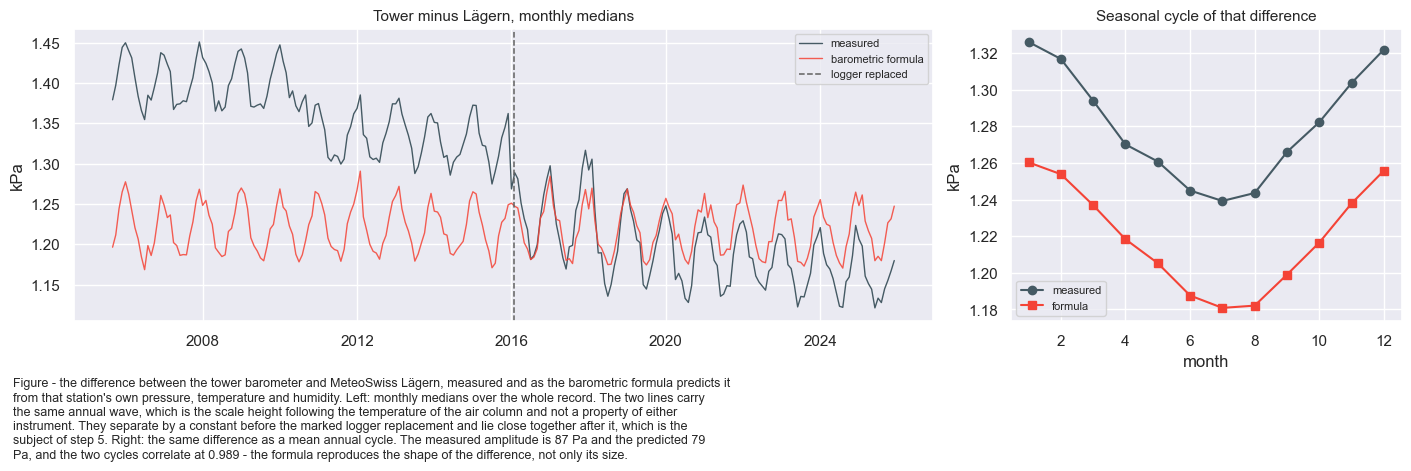

In [29]:
# The shape, not only the level. The prediction is computed per half-hour from the reference
# station's own pressure, temperature and humidity, and compared as monthly medians.
_pred_lae = predicted_pressure(pa_lae, ta_lae, vp_lae, LAE_ELEVATION - NOMINAL_ELEVATION)
_shape = pd.DataFrame({'measured': pa_2005_2025[TARGET] - pa_lae,
                       'predicted': _pred_lae - pa_lae}).resample('MS').median().dropna()
_clim = _shape.groupby(_shape.index.month).mean()

fig, axs = plt.subplots(ncols=2, figsize=(14, 4.6), dpi=100, layout='constrained',
                        width_ratios=[2.2, 1])
axs[0].plot(_shape.index, _shape['measured'], lw=1.0, color='#455A64', label='measured')
axs[0].plot(_shape.index, _shape['predicted'], lw=1.0, color='#F44336', alpha=.85,
            label='barometric formula')
axs[0].axvline(pd.Timestamp(ACQUISITION_CHANGE), color='#616161', ls='--', lw=1.1,
               label='logger replaced')
axs[0].set_ylabel('kPa')
axs[0].set_title('Tower minus Lägern, monthly medians', fontsize=11)
axs[0].legend(fontsize=8)
axs[1].plot(_clim.index, _clim['measured'], marker='o', color='#455A64', label='measured')
axs[1].plot(_clim.index, _clim['predicted'], marker='s', color='#F44336', label='formula')
axs[1].set_xlabel('month')
axs[1].set_ylabel('kPa')
axs[1].set_title('Seasonal cycle of that difference', fontsize=11)
axs[1].legend(fontsize=8)

_amp = (float(_clim['measured'].max() - _clim['measured'].min()),
        float(_clim['predicted'].max() - _clim['predicted'].min()))
_corr = float(_clim['measured'].corr(_clim['predicted']))
figcap(fig, f"the difference between the tower barometer and MeteoSwiss Lägern, measured and as "
            f"the barometric formula predicts it from that station's own pressure, temperature "
            f"and humidity. Left: monthly medians over the whole record. The two lines carry the "
            f"same annual wave, which is the scale height following the temperature of the air "
            f"column and not a property of either instrument. They separate by a constant before "
            f"the marked logger replacement and lie close together after it, which is the subject "
            f"of step 5. Right: the same difference as a mean annual cycle. The measured amplitude "
            f"is {_amp[0] * 1000:.0f} Pa and the predicted {_amp[1] * 1000:.0f} Pa, and the two "
            f"cycles correlate at {_corr:.3f} - the formula reproduces the shape of the "
            f"difference, not only its size.")

print(f"seasonal amplitude: measured {_amp[0]:.3f} kPa, predicted {_amp[1]:.3f} kPa")
print(f"correlation of the two annual cycles: {_corr:.4f}")
assert _corr > 0.9, (
    "the measured seasonal cycle of the tower-Laegern difference no longer follows the one the "
    "barometric formula predicts, so the agreement in the level above may be a coincidence")

### 4️⃣ Three barometers, and the pattern that names the one that moved

Three barometers give three pairwise differences, and each instrument appears in two of them. A
change at one therefore moves exactly its own two differences and leaves the third alone, which is
what turns "these two disagree" into "this one moved". It is the argument notebook `02` makes for
`TA` and `RADIATION_SENSOR_CONTINUITY.ipynb` makes for four radiation sensors, with one change: a
pressure error is **additive**, so barometers are compared by difference and never by ratio.

Two controls are built into the statistic rather than left to each call site. The difference
between two barometers at different heights has a seasonal cycle of about 0.09 kPa — step 3️⃣ shows
it is real physics — so monthly medians are taken first and then averaged over calendar months, and
a year short of a month does not enter at all. And the comparison is made year on year, so that the
size of a change is read against what these same three instruments do in an ordinary year.

In [30]:
TOWER, HUT, LAEGERN = 'tower 47 m', 'NABEL hut 2 m', 'MeteoSwiss Lägern'
BAROMETERS = {TOWER: pa_2005_2025[TARGET], HUT: pa_2005_2025[REFERENCE], LAEGERN: pa_lae}
PAIRS = [(TOWER, LAEGERN), (TOWER, HUT), (HUT, LAEGERN)]


def difference_by_year(a: str, b: str, min_records: int = 200) -> pd.Series:
    """Month-matched yearly mean of `a` - `b`, in kPa.

    Monthly medians first, then the mean over calendar months; a year not covering all twelve is
    dropped rather than compared against one that does. Raises rather than returning a thin
    result: a difference built from a handful of half-hours reads exactly like one built from
    thousands.
    """
    _d = (BAROMETERS[a] - BAROMETERS[b]).dropna()
    _m = _d.groupby([_d.index.year, _d.index.month]).median()
    _m.index.names = ['year', 'month']
    _m = _m[_d.groupby([_d.index.year, _d.index.month]).count() >= min_records]
    if _m.empty:
        raise ValueError(f"{a} - {b}: no calendar month reaches {min_records} records")
    _months = _m.groupby(level=0).count()
    return _m.groupby(level=0).mean()[_months == 12]


DIFFS = {_pair: difference_by_year(*_pair) for _pair in PAIRS}
diff_table = pd.DataFrame({f'{a} - {b}': _s for (a, b), _s in DIFFS.items()})
diff_table.index.name = 'YEAR'
change = diff_table.diff()
DECIDABLE = [int(_y) for _y in diff_table.index if diff_table.loc[_y].notna().all()
             and _y - 1 in diff_table.index and diff_table.loc[_y - 1].notna().all()]
print(f"years in which all three differences exist and can be compared with the year before: "
      f"{DECIDABLE[0]}-{DECIDABLE[-1]}")


def moved(changes: dict, threshold: float):
    """Which barometer a set of pairwise changes identifies, or None.

    Returns None when the pattern does not identify one - two instruments moving at once looks
    exactly like a row with several large entries, and a rule that guessed in that case would be
    worse than no rule. A difference says two barometers separated, never which of them left.
    """
    _big = {_p for _p, _v in changes.items() if pd.notna(_v) and abs(_v) >= threshold}
    if not _big:
        return None
    for _b in BAROMETERS:
        _own = {_p for _p in changes if _b in _p}
        if _big == _own:
            return _b
    return None


# The threshold is taken from what these three instruments do in an ordinary year rather than
# chosen round: a wall set below the year-to-year scatter would fire on nothing having happened.
EVENT_THRESHOLD = 0.04   # kPa
_typical = change.loc[DECIDABLE].abs().median()
assert EVENT_THRESHOLD > 2 * float(_typical.max()), (
    "the event threshold has fallen to within a factor of two of the ordinary year-to-year "
    "scatter of these differences, which would make it fire on ordinary weather and screening")

ATTRIBUTED = {_y: moved({_p: change.loc[_y, f'{_p[0]} - {_p[1]}'] for _p in PAIRS},
                        EVENT_THRESHOLD) for _y in DECIDABLE}

tabcap("each pairwise difference between the three barometers, year by year, in kPa. Monthly "
       "medians averaged over calendar months, so neither the season nor a year's gaps can move a "
       "row. A row is not a statement about the weather: all three instruments saw the same "
       "weather")
display(diff_table.round(4))

tabcap(f"the change in each difference from the previous year, and what the pattern of changes "
       f"identifies. A change at one barometer moves the two differences it appears in and no "
       f"other; the rule returns nothing where the pattern does not point at a single instrument. "
       f"Threshold {EVENT_THRESHOLD} kPa, against a typical year-to-year change of "
       f"{float(_typical.max()):.4f} kPa")
scan = change.loc[DECIDABLE].copy()
scan['identifies'] = [ATTRIBUTED[_y] or '' for _y in DECIDABLE]
display(scan.round(4))

_unattributed = [_y for _y in DECIDABLE if ATTRIBUTED[_y] is None]
_worst_quiet = float(change.loc[_unattributed].abs().max().max())
print(f"\nlargest change in any year the rule attributes to nobody: {_worst_quiet:.4f} kPa")
assert EVENT_THRESHOLD > _worst_quiet, (
    "a year the attribution rule cannot explain now carries a change larger than the event "
    "threshold, so either two instruments moved together or the threshold is wrong")
for _y, _who in ATTRIBUTED.items():
    if _who:
        print(f"  {_y}: {_who}")

years in which all three differences exist and can be compared with the year before: 2007-2017
Table - each pairwise difference between the three barometers, year by year, in kPa. Monthly medians
averaged over calendar months, so neither the season nor a year's gaps can move a row. A row is not
a statement about the weather: all three instruments saw the same weather



,tower 47 m - MeteoSwiss Lägern,tower 47 m - NABEL hut 2 m,NABEL hut 2 m - MeteoSwiss Lägern
YEAR,,,
2006,1.4031,-0.4034,1.8056
2007,1.4017,-0.4234,1.8246
2008,1.4010,-0.4271,1.8287
2009,1.3988,-0.4058,1.8046
2010,1.3853,-0.3966,1.7812
2011,1.3293,-0.3805,1.7104
2012,1.3359,-0.3690,1.7053
2013,1.3390,-0.3633,1.7026
2014,1.3226,-0.3651,1.6886


Table - the change in each difference from the previous year, and what the pattern of changes
identifies. A change at one barometer moves the two differences it appears in and no other; the rule
returns nothing where the pattern does not point at a single instrument. Threshold 0.04 kPa, against
a typical year-to-year change of 0.0140 kPa



,tower 47 m - MeteoSwiss Lägern,tower 47 m - NABEL hut 2 m,NABEL hut 2 m - MeteoSwiss Lägern,identifies
YEAR,,,,
2007,-0.0014,-0.0200,0.0190,
2008,-0.0007,-0.0037,0.0041,
2009,-0.0022,0.0213,-0.0241,
2010,-0.0134,0.0092,-0.0234,
2011,-0.0561,0.0160,-0.0708,MeteoSwiss Lägern
2012,0.0067,0.0115,-0.0051,
2013,0.0031,0.0057,-0.0027,
2014,-0.0164,-0.0018,-0.0140,
2015,0.0059,0.0034,0.0023,



largest change in any year the rule attributes to nobody: 0.0241 kPa
  2011: MeteoSwiss Lägern
  2016: tower 47 m
  2017: NABEL hut 2 m


In [31]:
# The guards guard. The attribution rule has to refuse the cases it exists to refuse, or a table
# with several large entries would be read as an identification.
_all_pairs_move = {_p: 0.5 for _p in PAIRS}
assert moved(_all_pairs_move, EVENT_THRESHOLD) is None, \
    "(!) the rule named a barometer when all three differences moved, which identifies nothing"
_one_pair_moves = {_p: (0.5 if _p == PAIRS[0] else 0.0) for _p in PAIRS}
assert moved(_one_pair_moves, EVENT_THRESHOLD) is None, \
    "(!) the rule named a barometer from a single moving difference, which says two separated"
_tower_moves = {_p: (0.5 if TOWER in _p else 0.0) for _p in PAIRS}
assert moved(_tower_moves, EVENT_THRESHOLD) == TOWER, \
    "(!) the rule failed to name the tower when exactly its own two differences moved"
print("OK: the attribution rule names an instrument only when exactly its own two differences "
      "move, and returns nothing otherwise.")

try:
    difference_by_year(TOWER, LAEGERN, min_records=10_000_000)
except ValueError as _exc:
    print(f"OK, difference_by_year raised on a threshold no month can meet: {_exc}")
else:
    raise AssertionError("(!) difference_by_year accepted a threshold no data can meet.")

OK: the attribution rule names an instrument only when exactly its own two differences move, and returns nothing otherwise.
OK, difference_by_year raised on a threshold no month can meet: tower 47 m - MeteoSwiss Lägern: no calendar month reaches 10000000 records


The scan finds three events, and only one of them is at this tower.

- **2011** — both differences containing MeteoSwiss move and the one between the two site
  barometers does not. That places the change at the reference station, and it is the same event
  the radiation notebooks date to **6 October 2010**, when Lägern's instrumentation was rebuilt.
  A tower-minus-Lägern comparison is therefore not evidence about this tower across that date.
- **2016** — both differences containing the tower move, by the same amount, and the difference
  between the two references does not move at all. That is the tower barometer, and it is treated
  in step 5️⃣.
- **2017** — both differences containing the hut barometer move. That instrument was in its last
  years and stopped altogether in July 2018, which is also when its slot began repeating the tower
  series.

Everywhere else the three instruments hold their differences to a few hundredths of a kPa for two
decades.

### 5️⃣ The January 2016 acquisition change: the tower barometer steps

This is the one positive result in the section. The record before the changeover sits about
0.09 kPa above the record after it; both references see the same step to within a thousandth of a
kPa, and they do not move against each other, so the step is on the tower barometer.

The date is fixed by three files that were written independently of one another. The record carries
a three-week outage that ends on **21 January 2016**, so the step is bracketed and cannot be dated
more finely than that gap. The logger program on disk is the version of **18 January 2016**. And
the fieldbook, in step 7️⃣, names that same program file.

Which of the two eras is the correct one is not a matter of opinion here, because step 3️⃣ can ask
the question absolutely: the later era agrees with the barometric formula and the earlier era does
not, against **both** references.

In [32]:
BREAK_YEAR = pd.Timestamp(ACQUISITION_CHANGE).year

# 1. the size of the step, from the two differences the tower appears in
tabcap(f"the step at the {BREAK_YEAR} acquisition change in each pairwise difference, against the "
       f"typical and the largest change these same differences show in a year with no event")
_rows = []
for _pair in PAIRS:
    _label = f'{_pair[0]} - {_pair[1]}'
    _quiet = change.loc[[_y for _y in _unattributed], _label]
    _rows.append({'pair': _label, f'change across {BREAK_YEAR} (kPa)': change.loc[BREAK_YEAR, _label],
                  'contains the tower': TOWER in _pair,
                  'median |change| in a quiet year (kPa)': float(_quiet.abs().median()),
                  'largest |change| in a quiet year (kPa)': float(_quiet.abs().max())})
step_table = pd.DataFrame(_rows).set_index('pair')
display(step_table.round(4))

_tower_steps = step_table.loc[step_table['contains the tower'], f'change across {BREAK_YEAR} (kPa)']
_ref_step = float(step_table.loc[~step_table['contains the tower'],
                                 f'change across {BREAK_YEAR} (kPa)'].iloc[0])
STEP_2016 = float(_tower_steps.mean())
print(f"\nthe two differences containing the tower move by "
      f"{', '.join(f'{_v:+.4f}' for _v in _tower_steps)} kPa, i.e. by the same amount to "
      f"{abs(float(_tower_steps.diff().iloc[-1])):.4f} kPa;")
print(f"the difference between the two references moves by {_ref_step:+.4f} kPa.")
print(f"step attributed to the tower barometer: {STEP_2016:+.4f} kPa "
      f"({STEP_2016 / KPA_PER_METRE:+.0f} m of air, {100 * STEP_2016 / 93.3:+.3f} % of the value)")

assert ATTRIBUTED[BREAK_YEAR] == TOWER, (
    f"the {BREAK_YEAR} change is no longer attributed to the tower barometer by the pattern of "
    f"pairwise differences, so this whole step must be re-derived")
assert abs(_ref_step) < EVENT_THRESHOLD / 4, (
    "the two references now move against each other at the acquisition change as well, which "
    "would mean the step cannot be placed on the tower from these three instruments")
assert STEP_2016 < 0, "the sign of the 2016 step has reversed"

Table - the step at the 2016 acquisition change in each pairwise difference, against the typical and
the largest change these same differences show in a year with no event



,change across 2016 (kPa),contains the tower,median |change| in a quiet year (kPa),largest |change| in a quiet year (kPa)
pair,,,,
tower 47 m - MeteoSwiss Lägern,-0.0884,True,0.0045,0.0164
tower 47 m - NABEL hut 2 m,-0.0888,True,0.0074,0.0213
NABEL hut 2 m - MeteoSwiss Lägern,-0.0001,False,0.0095,0.0241



the two differences containing the tower move by -0.0884, -0.0888 kPa, i.e. by the same amount to 0.0004 kPa;
the difference between the two references moves by -0.0001 kPa.
step attributed to the tower barometer: -0.0886 kPa (-8 m of air, -0.095 % of the value)


In [33]:
# 2. the outage that brackets it, found in the record rather than assumed
_measured = pa_2005_2025[TARGET]
_present = _measured.loc[f'{BREAK_YEAR - 1}-11-01':f'{BREAK_YEAR}-03-31'].notna()
_gaps, _run_start = [], None
for _ts, _ok in _present.items():
    if not _ok and _run_start is None:
        _run_start = _ts
    elif _ok and _run_start is not None:
        _gaps.append((_run_start, _ts - pd.Timedelta(minutes=30)))
        _run_start = None
_gaps = sorted(_gaps, key=lambda ab: ab[1] - ab[0], reverse=True)
OUTAGE_START, OUTAGE_END = _gaps[0]
OUTAGE_DAYS = (OUTAGE_END - OUTAGE_START) / pd.Timedelta(days=1)
print(f"longest outage around the changeover: {OUTAGE_START} -> {OUTAGE_END} "
      f"({OUTAGE_DAYS:.1f} days)")
print(f"the record resumes on {(OUTAGE_END + pd.Timedelta(minutes=30)):%d %b %Y %H:%M}")
assert (OUTAGE_END + pd.Timedelta(minutes=30)).normalize() == pd.Timestamp(ACQUISITION_CHANGE), (
    f"the record no longer resumes on {ACQUISITION_CHANGE}, so the date this notebook uses for the "
    f"acquisition change is not the date the record itself gives")
assert OUTAGE_DAYS > 5, (
    "the outage no longer brackets the changeover, so the step could in principle be dated more "
    "finely than this notebook claims - or less")

# 3. which era is right, asked absolutely
tabcap("the departure of the measured difference from the one the barometric formula predicts, by "
       "acquisition era and by reference. This is the question a relative comparison cannot "
       "answer: the formula is not fitted to either era, so a period that sits on it is at the "
       "right absolute level")
_pred = {LAEGERN: predicted_pressure(pa_lae, ta_lae, vp_lae, LAE_ELEVATION - NOMINAL_ELEVATION),
         HUT: predicted_pressure(pa_2005_2025[REFERENCE], ta_lae, vp_lae,
                                 (SITE_BASE_ELEVATION + HUT_HEIGHT) - NOMINAL_ELEVATION)}
_rows = []
for _ref, _p in _pred.items():
    _r = (pa_2005_2025[TARGET] - _p).dropna()
    for _era, _sl in [(f'CR10X, to {ACQUISITION_CHANGE}',
                       slice('2011-01-01', pd.Timestamp(ACQUISITION_CHANGE) - pd.Timedelta(days=1))),
                      (f'CR1000, from {ACQUISITION_CHANGE}', slice(ACQUISITION_CHANGE, None))]:
        _x = _r.loc[_sl]
        if len(_x) < 10_000:
            continue
        _m = _x.groupby([_x.index.year, _x.index.month]).median()
        _rows.append({'reference': _ref, 'era': _era, 'n': len(_x),
                      'measured - predicted (kPa)': float(_m.mean()),
                      'in metres of air': float(_m.mean()) / KPA_PER_METRE})
era_table = pd.DataFrame(_rows).set_index(['reference', 'era'])
display(era_table.round(4))

# The earlier era is restricted to 2011 onwards so that the reference station's own step of
# October 2010 does not enter the comparison; the point of this table is the tower, not Laegern.
_late = era_table.xs(f'CR1000, from {ACQUISITION_CHANGE}', level='era')['measured - predicted (kPa)']
_early = era_table.xs(f'CR10X, to {ACQUISITION_CHANGE}', level='era')['measured - predicted (kPa)']
print(f"\nCR1000 era: {_late.abs().max():.3f} kPa from the barometric prediction at worst")
print(f"CR10X era:  {_early.abs().min():.3f} kPa at best")
assert _late.abs().max() < _early.abs().min(), (
    "the earlier era is now closer to the barometric prediction than the later one against at "
    "least one reference, which reverses the reading given here")
assert _late.abs().max() < 0.05, (
    "the later era has drifted away from the barometric prediction, so it can no longer be "
    "described as the era that agrees with the physics")
print("The later era sits on the barometric prediction against both references; the earlier era "
      "sits above it by about the size of the step. The pre-2016 record reads high.")

longest outage around the changeover: 2016-01-01 00:15:00 -> 2016-01-21 13:45:00 (20.6 days)
the record resumes on 21 Jan 2016 14:15
Table - the departure of the measured difference from the one the barometric formula predicts, by
acquisition era and by reference. This is the question a relative comparison cannot answer: the
formula is not fitted to either era, so a period that sits on it is at the right absolute level



n  measured - predicted (kPa)  in metres of air
reference         era                                                                          
MeteoSwiss Lägern CR10X, to 2016-01-21      86108                      0.1100            9.7706
                  CR1000, from 2016-01-21  173295                     -0.0271           -2.4019
NABEL hut 2 m     CR10X, to 2016-01-21      86201                      0.1419           12.5948
                  CR1000, from 2016-01-21   42883                      0.0173            1.5388


CR1000 era: 0.027 kPa from the barometric prediction at worst
CR10X era:  0.110 kPa at best
The later era sits on the barometric prediction against both references; the earlier era sits above it by about the size of the step. The pre-2016 record reads high.


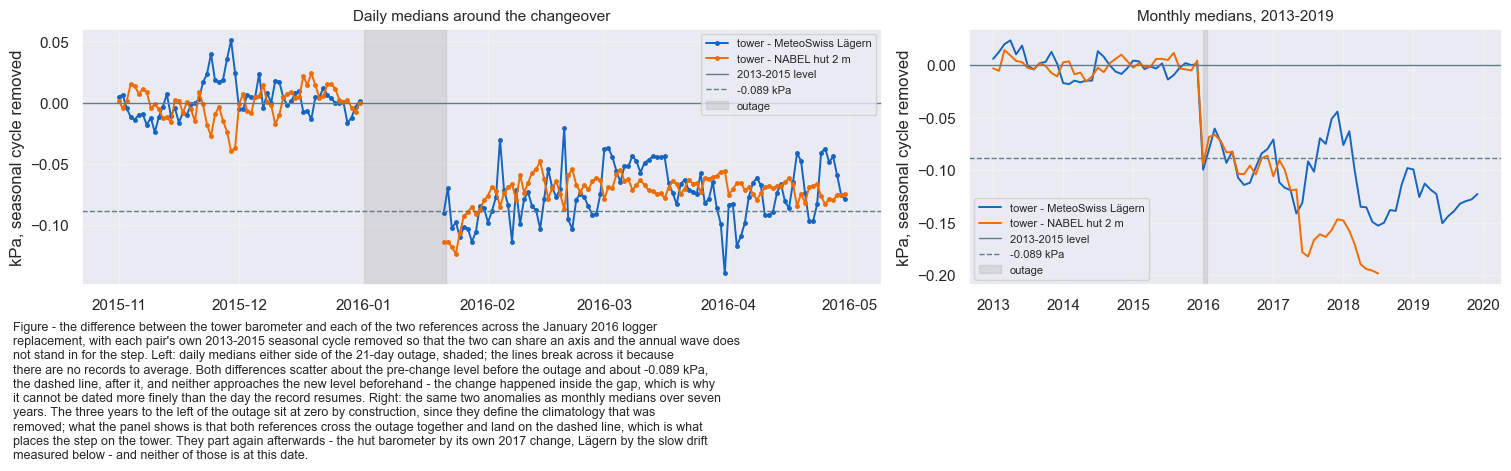

In [34]:
# The step, at the resolution that shows it is a step and not a drift. Two things have to come out
# of the picture first. The two differences sit 1.7 kPa apart, so on a shared absolute axis a change
# of 0.09 kPa is a line thickness; and each carries the annual wave of step 3, whose amplitude is
# about the same size as the step, so a November-to-April window would show one mixed with the
# other. Both are removed by subtracting each pair's own monthly climatology over the three years
# before the changeover: the pre-change era then sits at zero by construction, and anything else is
# a departure from it.
_CLIM_YEARS = slice(f'{BREAK_YEAR - 3}', f'{BREAK_YEAR - 1}')


def seasonal_anomaly(ref: str) -> pd.Series:
    """Tower minus `ref`, with that pair's own pre-change monthly climatology removed."""
    _full = pa_2005_2025[TARGET] - BAROMETERS[ref]
    _clim = _full.loc[_CLIM_YEARS].groupby(_full.loc[_CLIM_YEARS].index.month).median()
    return _full - _full.index.month.map(_clim)


fig, axs = plt.subplots(ncols=2, figsize=(15, 4.6), dpi=100, layout='constrained',
                        width_ratios=[1.5, 1])
for _ax, _win, _freq, _title in [
        (axs[0], slice(f'{BREAK_YEAR - 1}-11-01', f'{BREAK_YEAR}-04-30'), '1D',
         'Daily medians around the changeover'),
        (axs[1], slice(f'{BREAK_YEAR - 3}', f'{BREAK_YEAR + 3}'), 'MS',
         f'Monthly medians, {BREAK_YEAR - 3}-{BREAK_YEAR + 3}')]:
    for _ref, _colour in [(LAEGERN, '#1565C0'), (HUT, '#EF6C00')]:
        # No dropna: an empty bin stays NaN, so the line breaks at the outage instead of drawing a
        # straight segment across it that would look like the sensor moving during the gap.
        _d = seasonal_anomaly(_ref).loc[_win].resample(_freq).median()
        _ax.plot(_d.index, _d.values, lw=1.4, marker='o' if _freq == '1D' else None, ms=2.5,
                 color=_colour, label=f'tower - {_ref}')
    _ax.axhline(0, color='#607D8B', lw=1.0, label=f'{BREAK_YEAR - 3}-{BREAK_YEAR - 1} level')
    _ax.axhline(STEP_2016, color='#607D8B', lw=1.0, ls='--', label=f'{STEP_2016:+.3f} kPa')
    _ax.axvspan(OUTAGE_START, OUTAGE_END, color='#9E9E9E', alpha=.25, label='outage')
    _ax.set_ylabel('kPa, seasonal cycle removed')
    _ax.set_title(_title, fontsize=11)
    _ax.legend(fontsize=8)
    _ax.grid(alpha=.3)

figcap(fig, f"the difference between the tower barometer and each of the two references across the "
            f"January {BREAK_YEAR} logger replacement, with each pair's own "
            f"{BREAK_YEAR - 3}-{BREAK_YEAR - 1} seasonal cycle removed so that the two can share an "
            f"axis and the annual wave does not stand in for the step. Left: daily medians either "
            f"side of the {OUTAGE_DAYS:.0f}-day outage, shaded; the lines break across it because "
            f"there are no records to average. Both differences scatter about the pre-change level "
            f"before the outage and about {STEP_2016:+.3f} kPa, the dashed line, after it, and "
            f"neither approaches the new level beforehand - the change happened inside the gap, "
            f"which is why it cannot be dated more finely than the day the record resumes. Right: "
            f"the same two anomalies as monthly medians over seven years. The three years to the "
            f"left of the outage sit at zero by construction, since they define the climatology "
            f"that was removed; what the panel shows is that both references cross the outage "
            f"together and land on the dashed line, which is what places the step on the tower. "
            f"They part again afterwards - the hut barometer by its own {BREAK_YEAR + 1} change, "
            f"Lägern by the slow drift measured below - and neither of those is at this date.")

One more number belongs beside the step, because it bears on whether correcting the step
would be worth doing. The tower-minus-Lägern difference also falls slowly across the whole record.
Taking out the two events the scan attributes — the 2010 rebuild at Lägern and the 2016 step here —
leaves a residual drift of the same order as the step itself, and more than half of it falls after
the hut barometer stops, where nothing can say which of the two instruments is moving.

In [35]:
_ms_by_year = diff_table[f'{TOWER} - {LAEGERN}']
_first, _last = int(_ms_by_year.index.min()), int(_ms_by_year.index.max())
_total = float(_ms_by_year.loc[_last] - _ms_by_year.loc[_first])
_events = {_y: float(change.loc[_y, f'{TOWER} - {LAEGERN}'])
           for _y, _who in ATTRIBUTED.items() if _who is not None}
_residual = _total - sum(_events.values())
_last_witness = int(pa_2005_2025[REFERENCE].last_valid_index().year)
_after = float(_ms_by_year.loc[_last] - _ms_by_year.loc[_last_witness])

tabcap(f"the total change in the tower-minus-Lägern difference over the record, split into the "
       f"events the attribution rule identified and what is left over. The residual is a drift "
       f"without a date, so there is no boundary at which a correction could be applied to it")
display(pd.DataFrame(
    {'kPa': {f'total, {_first} to {_last}': _total,
             **{f'attributed to {ATTRIBUTED[_y]} at {_y}': _v for _y, _v in _events.items()},
             'residual drift, unattributed': _residual,
             f'of which after {_last_witness}, with no second barometer': _after}}).round(4))

print(f"\nresidual drift over {_last - _first} years: {_residual:+.4f} kPa "
      f"({_residual / KPA_PER_METRE:+.0f} m of air), against a step of {STEP_2016:+.4f} kPa")
print(f"share of it falling after the hut barometer stops: {100 * _after / _residual:.0f} %")
assert abs(_residual) > abs(STEP_2016) / 2, (
    "the unattributed drift has become small beside the 2016 step, which removes one of the three "
    "reasons the callout below gives for not correcting the step")

Table - the total change in the tower-minus-Lägern difference over the record, split into the events
the attribution rule identified and what is left over. The residual is a drift without a date, so
there is no boundary at which a correction could be applied to it



,kPa
"total, 2006 to 2025",-0.2457
attributed to MeteoSwiss Lägern at 2011,-0.0561
attributed to tower 47 m at 2016,-0.0884
attributed to NABEL hut 2 m at 2017,-0.0034
"residual drift, unattributed",-0.0978
"of which after 2018, with no second barometer",-0.0520



residual drift over 19 years: -0.0978 kPa (-9 m of air), against a step of -0.0886 kPa
share of it falling after the hut barometer stops: 53 %


::: {.callout-important title="Why the step is reported and not corrected"}
The step is real, dated and attributed: the same barometer, converted with the same two numbers,
read single-ended by one logger and differentially by the next, with the earlier era sitting about
a tenth of a kPa above the barometric prediction and the later era on it. A correction is therefore
defensible, and this notebook does not apply one. Three reasons, in order of weight:

- **Size.** The step is one part in a thousand of the value and under ten metres of air. Air
  density, and the flux quantities computed from it, change by the same one part in a thousand.
- **What it would cost.** Homogenising the record means exporting a second, rescaled column and a
  `SOURCE` flag naming the acquisition era, on the pattern notebooks `02`, `08` and `09` follow.
  That changes the columns this product ships and the merged product built from them, which is a
  decision about the dataset rather than about this variable.
- **What is left over.** The residual drift measured just above is of the same order as the step,
  has no date at which a correction could be applied, and after 2018 cannot be attributed to an
  instrument at all. A homogenisation would remove the step and leave that.

Anyone who needs one absolute level across the whole record should subtract the step, printed
above, from the records before `ACQUISITION_CHANGE`; the later era is the one to keep.
:::

### 6️⃣ No step at the December 2021 screening splice

`meteoscreening_mst` ends on 31 December 2021 and `meteoscreening_diive` begins the next day. The
two do not overlap, so the splice can only be judged by continuity — and it is a *screening*
boundary, not a hardware one: the fieldbook records no work on this sensor then, and the logger
program did not change.

By this point the hut barometer has been gone for three years, so only the difference against
MeteoSwiss is available and the pattern rule of step 4️⃣ cannot be applied. What can be asked is
whether that difference does anything at the boundary that it does not do in an ordinary year. It
does not: the change across the splice is **smaller** than the median change from one year to the
next, and the three-year statistic there sits between the values of its own neighbours, which is
the slow drift and not a splice.

In [36]:
SCREENING_YEAR = 2022   # the first year screened by diive; mst ends on 31 Dec 2021
_ms_label = f'{TOWER} - {LAEGERN}'
_ms = diff_table[_ms_label]


def step_at(series: pd.Series, year: int, span: int = 3) -> float:
    """Change of a yearly difference across `year`, over `span` years either side, in kPa.

    The candidate year itself is excluded from both sides. Returns nan rather than a number when
    either side is thin, so a year at the edge of the record cannot win a comparison by having
    almost no data behind it.
    """
    _pre = series.reindex(range(year - span, year)).dropna()
    _post = series.reindex(range(year + 1, year + 1 + span)).dropna()
    if len(_pre) < 2 or len(_post) < 2:
        return float('nan')
    return float(_post.mean() - _pre.mean())


assert np.isnan(step_at(_ms, 1990)), "(!) step_at returned a number for a year off the record"
assert np.isnan(step_at(_ms, int(_ms.index.max()))), \
    "(!) step_at returned a number for the last year of the record"

_adjacent = _ms.diff()
_quiet_adjacent = _adjacent.drop(index=[_y for _y in (2011, 2016, 2017, SCREENING_YEAR)
                                        if _y in _adjacent.index]).abs()
tabcap(f"what the tower-minus-Lägern difference does at the {SCREENING_YEAR - 1}/"
       f"{SCREENING_YEAR} screening boundary, beside the same statistics in the years around it. "
       f"A step lands entirely in the one-year change; the three-year change is dominated by the "
       f"slow drift of this difference and is reported so that the two are not confused")
splice_table = pd.DataFrame({
    'one-year change (kPa)': {_y: _adjacent.get(_y, float('nan'))
                              for _y in range(SCREENING_YEAR - 2, SCREENING_YEAR + 3)},
    'three-year change (kPa)': {_y: step_at(_ms, _y)
                                for _y in range(SCREENING_YEAR - 2, SCREENING_YEAR + 3)},
})
splice_table.index.name = 'YEAR'
display(splice_table.round(4))

_here = float(_adjacent.loc[SCREENING_YEAR])
_typical_adj = float(_quiet_adjacent.median())
print(f"\nchange across the splice:            {_here:+.4f} kPa "
      f"({_here / KPA_PER_METRE:+.1f} m of air)")
print(f"median change in an ordinary year:   {_typical_adj:.4f} kPa")
print(f"change across the 2016 hardware date: {change.loc[BREAK_YEAR, _ms_label]:+.4f} kPa")
assert abs(_here) < EVENT_THRESHOLD, (
    f"the tower-Laegern difference now moves by {_here:+.4f} kPa across the screening splice, past "
    f"the {EVENT_THRESHOLD} kPa an event is counted at - the mst/diive splice can no longer be "
    f"reported as clean")
assert abs(_here) < _typical_adj, (
    "the change across the screening splice is no longer smaller than what this difference does in "
    "an ordinary year, which is the statement this step makes")
_neighbours = [step_at(_ms, _y) for _y in (SCREENING_YEAR - 1, SCREENING_YEAR + 1)]
assert min(_neighbours) <= step_at(_ms, SCREENING_YEAR) <= max(_neighbours), (
    "the three-year change at the splice is no longer between the values of its own neighbours, so "
    "it is no longer just the slow drift passing through")
print("\nNothing happens at the screening boundary that does not happen in an ordinary year. The "
      "two screenings of this measurement can be joined.")

Table - what the tower-minus-Lägern difference does at the 2021/2022 screening boundary, beside the
same statistics in the years around it. A step lands entirely in the one-year change; the three-year
change is dominated by the slow drift of this difference and is reported so that the two are not
confused



,one-year change (kPa),three-year change (kPa)
YEAR,,
2020,-0.0199,-0.0388
2021,0.0002,-0.0262
2022,-0.0032,-0.0253
2023,-0.0115,-0.0197
2024,-0.0007,NaN



change across the splice:            -0.0032 kPa (-0.3 m of air)
median change in an ordinary year:   0.0062 kPa
change across the 2016 hardware date: -0.0884 kPa

Nothing happens at the screening boundary that does not happen in an ordinary year. The two screenings of this measurement can be joined.


### 7️⃣ What the maintenance record holds for this barometer

Evidence first, fieldbook second: the data have located the one date that matters, and the
fieldbook is now asked what happened there. Two questions are put to it — what it says about the
barometer, and what it says about the January 2016 changeover.

In [37]:
# The maintenance record, read and filtered here rather than quoted, so a newer export
# re-derives this instead of leaving a stale copy in the prose.
fb = pd.read_csv(FIELDBOOK)
fb['Date'] = pd.to_datetime(fb['Date'], format='%d.%m.%Y', errors='coerce')
fb['text'] = fb['Text'].apply(strip_html)
audit_unmapped_names(fb['text'], 'fieldbook entries')
print(f"fieldbook: {len(fb):,} entries, {fb['Date'].min().date()} -> {fb['Date'].max().date()}")
_dev = fb[['Device Name', 'Device Model']].astype(str).agg(' '.join, axis=1)

# Question 1: does this barometer appear at all? Device columns AND free text, because the entries
# that explain a fault are routinely filed under something else.
BAROMETER = r'PTB\s*-?\s*101|barometer|barometric|Vaisala|Luftdruck'
_by_device = _dev.str.contains(BAROMETER, case=False, regex=True, na=False)
_by_text = fb['text'].str.contains(BAROMETER, case=False, regex=True, na=False)
print(f"\nentries naming a barometer: {int(_by_device.sum())} by device column, "
      f"{int(_by_text.sum())} by free text")


def fragment(text, pattern, width=40) -> str:
    """The part of one entry that matches, rather than its first hundred characters.

    Several of these entries are whole-day visit reports in which the matching word appears once,
    halfway through; truncating from the start shows the drive to the site instead.
    """
    _m = re.search(pattern, str(text), re.I)
    if not _m:
        return str(text)[:2 * width]
    _lo, _hi = max(0, _m.start() - width), min(len(str(text)), _m.end() + width)
    return ('...' if _lo else '') + str(text)[_lo:_hi] + ('...' if _hi < len(str(text)) else '')


for _, _r in fb[_by_device | _by_text].sort_values('Date').iterrows():
    print(f"  {_r['Date'].date()} [{_r['Device Model']}] {fragment(_r['text'], BAROMETER)}")

assert int(_by_device.sum()) == 0, (
    "a barometer now appears in the device inventory, so the statement that this instrument is "
    "absent from the maintenance record is out of date")

# The word 'pressure' on its own is about something else here, and saying so is part of the
# answer: a filter that counted those would report maintenance on a sensor that has had none.
_pressure = fb['text'].str.contains(r'\bpressure\b|\bDruck\w*', case=False, regex=True, na=False)
print(f"\nentries containing the word 'pressure' or 'Druck': {int(_pressure.sum())}, none of them "
      f"about this instrument. What they are about:")
_ctx = sorted({_m.group(0).strip().lower()
               for _t in fb.loc[_pressure, 'text']
               for _m in re.finditer(r'(?:\w+\s+){0,2}(?:pressure|Druck\w*)', str(_t), re.I)})
print(textwrap.fill('; '.join(_ctx[:24]), 110))
assert not fb.loc[_pressure, 'text'].str.contains(
    r'(?:replac|calibrat|clean)\w*\s+(?:the\s+)?(?:PTB|barometer|pressure sensor)',
    case=False, regex=True, na=False).any(), (
    "the fieldbook now records work on the barometer itself, which the sections above and the "
    "documentation page both state does not exist")
print("\nIn twenty-one years the barometer is never named: not replaced, not calibrated, not "
      "cleaned, and not in the device inventory. Every occurrence of the word 'pressure' is about "
      "a gas cylinder, a flow regulator or an analyser.")

  fieldbook entries: no unmapped name-shaped tokens (58 allowlisted terms)
fieldbook: 2,102 entries, 2003-10-24 -> 2026-07-17

entries naming a barometer: 0 by device column, 1 by free text
  2023-01-03 [na] ...data acquisition of the PWD12 using the vaisala script of person 20. The sensor was ins...

entries containing the word 'pressure' or 'Druck': 20, none of them about this instrument. What they are about:
ansaugstellen mit druckluft; aufgrund der druckabhaengigkeit; but pressure; check tank pressure; checking tank
pressure; der druckabfall; die druckdifferenz; druck; drucks; ein deutlicher drucksprung; flush the pressure;
initial pressure; low level pressure; more stable pressure; of the pressure; pressure; profil
druckabhaengigkeit; reference flask pressure; relativ grosser drucksprung; the internal pressure; the
pressure; und ungenauen druckkompensation; values when pressure; zu diesem druckabfall

In twenty-one years the barometer is never named: not replaced, not calibrated, 

In [38]:
# Question 2: what the record holds for the January 2016 acquisition change. Entries dated
# 1 January 2016 are the GIN inventory import rather than events and are excluded, as elsewhere.
TOWER_LOGGER = r'iDL_T1_47_1|CR1000_T1_47_1|CH-LAE_T1_47'
_win = fb[fb['Date'].between(f'{BREAK_YEAR - 1}-12-01', f'{BREAK_YEAR}-03-31')
          & (fb['Date'] != f'{BREAK_YEAR}-01-01')]
_hits = _win[_win['text'].str.contains(TOWER_LOGGER, regex=True, na=False)
             | _dev.reindex(_win.index).str.contains(TOWER_LOGGER, regex=True, na=False)
             | _win['Operation Tag'].astype(str).str.contains(TOWER_LOGGER, regex=True, na=False)
             | _win['Location'].astype(str).str.contains(TOWER_LOGGER, regex=True, na=False)]
assert len(_hits) > 0, (
    "no fieldbook entries at all for the tower logger around the changeover - has the export "
    "format changed?")

tabcap(f"every fieldbook entry naming the tower logger between December {BREAK_YEAR - 1} and "
       f"March {BREAK_YEAR}, shown around the words that name it. The inventory rows dated "
       f"1 January are excluded because they are the GIN import rather than events")
_show = _hits[['Date', 'Device Model', 'Operation Tag', 'text']].copy()
_show['Date'] = _show['Date'].dt.date
_show['text'] = _show['text'].apply(lambda _t: fragment(_t, TOWER_LOGGER, width=70))
with pd.option_context('display.max_colwidth', 150):
    display(_show.set_index('Date'))

# The program on disk carries a version date in its folder name. If the fieldbook names the same
# file, then the program this notebook parsed is the program that was actually running.
PROGRAM_VERSION = re.search(r'(\d{8})', Path(PROGRAM_AFTER).parent.name).group(1)
_named = _hits[_hits['text'].str.contains(PROGRAM_VERSION, na=False)]
print(f"\nprogram folder on disk carries version {PROGRAM_VERSION} "
      f"({pd.Timestamp(PROGRAM_VERSION):%d %b %Y})")
print(f"fieldbook entries naming that version: {len(_named)}")
for _, _r in _named.iterrows():
    print(f"  {_r['Date'].date()}  {fragment(_r['text'], PROGRAM_VERSION, width=70)}")
assert len(_named) > 0, (
    "the fieldbook no longer names the logger program version this notebook parses, so the "
    "identification of the program that was running at the changeover rests on the file name alone")
assert pd.Timestamp(PROGRAM_VERSION) < pd.Timestamp(ACQUISITION_CHANGE), (
    "the logger program on disk is dated after the record resumes, so it cannot be the program "
    "that produced the first values of the later era")
print(f"\nThe program parsed above is dated "
      f"{(pd.Timestamp(ACQUISITION_CHANGE) - pd.Timestamp(PROGRAM_VERSION)).days} days before "
      f"the record resumes, and the fieldbook names that same file. The record, the program "
      f"and the maintenance log agree on the date without having been made to.")

Table - every fieldbook entry naming the tower logger between December 2015 and March 2016, shown
around the words that name it. The inventory rows dated 1 January are excluded because they are the
GIN import rather than events



,Device Model,Operation Tag,text
Date,,,
2016-02-10,CR1000,CH-LAE_iDL_T1_47_1,Added device to site.
2016-02-10,na,na,...loaded logger data to avoid data gaps data download for tower logger iCR1000_T1_47_1 was interrupted but could downloaded using loggernet (pakb...
2016-01-27,na,na,... to SC raspi –> ok downloaded the tablefiles from the ““meteologger”” iDL_T1_47_1



program folder on disk carries version 20160118 (18 Jan 2016)
fieldbook entries naming that version: 1
  2016-02-10  ...estarted logger and uploaded the logger program CH-LAE_CR1000_T1_47_1-20160118.CR1 again. Everything back to normal. With the data files on the emeb...

The program parsed above is dated 3 days before the record resumes, and the fieldbook names that same file. The record, the program and the maintenance log agree on the date without having been made to.


#### What this section settles

`PA_T1_47_1` is **one instrument over the whole record** — a Vaisala PTB101B, converted with the
same multiplier and offset by every logger program that has ever measured it, and never replaced,
calibrated or cleaned as far as the maintenance record goes. Its **absolute level is right**: the
barometric formula, with nothing fitted, puts the barometer within a few metres of where it hangs
from each of two independent references, and reproduces the seasonal shape of the difference as
well as its size.

The record is **not homogeneous**. At the January 2016 acquisition change the level steps by about
0.09 kPa, on the tower rather than on either reference, and the later era is the one that agrees
with the physics. The series is still exported as measured, for the reasons in the callout above,
so a user who needs one absolute level across twenty years has to apply that step themselves. The
**December 2021 screening splice is clean**, and that absence is a claim the assertions above keep
true.

***

### Dataframe

In [39]:
tabcap("the working dataframe after every correction, and the distribution of both columns. The reference column is diagnostic and is dropped before export")
display(pa_2005_2025)
pa_2005_2025.describe()

Table - the working dataframe after every correction, and the distribution of both columns. The
reference column is diagnostic and is dropped before export



,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


,PA_T1_47_1,PA_NABEL_H1_2_1
count,352438.000000,224449.000000
mean,93.231834,93.661485
std,0.738882,0.748588
min,89.446007,89.786333
25%,92.849998,93.261600
50%,93.306183,93.738947
75%,93.697846,94.146000
max,95.543335,96.029917


***

## 🚫 No gap-filling here

Notebooks `01`-`03` produce gap-filled products. This one does not, and the series is exported as
measured.

Pressure would in fact be the easiest of these variables to fill — it is smooth, strongly
autocorrelated, and a nearby barometer tracks it closely throughout. That is precisely why the
decision matters and is recorded here rather than assumed: a filled `PA` would look almost
indistinguishable from a measured one, so downstream users could not tell them apart without a
flag, and this product deliberately ships only measurements.

The numbers below are computed rather than written down, so that they cannot go stale.

In [40]:
_missing = pa_2005_2025[TARGET].isna()
_runs = _missing.groupby((~_missing).cumsum()).transform('sum').where(_missing, 0)
_gap_lengths = pd.Series([int(_g) for _g in _runs[_missing].groupby((~_missing).cumsum()).max()])

print(f"records:            {len(pa_2005_2025):,}")
print(f"measured:           {int((~_missing).sum()):,} ({100 * (~_missing).mean():.2f} %)")
print(f"missing:            {int(_missing.sum()):,} ({100 * _missing.mean():.2f} %)")
print(f"separate gaps:      {len(_gap_lengths):,}")
print(f"of those, <= 1 h:   {int((_gap_lengths <= 2).sum()):,}")
print(f"longest gap:        {int(_gap_lengths.max()):,} records "
      f"({_gap_lengths.max() / 48:.1f} days)")

tabcap("how the missing half-hours are distributed over gap lengths. Most of the gaps are short "
       "and most of the missing records are in a handful of long ones, which is the distinction "
       "that matters to anyone deciding whether to interpolate")
_bins = pd.cut(_gap_lengths, [0, 2, 12, 48, 480, 10 ** 6],
               labels=['<= 1 h', '1-6 h', '6-24 h', '1-10 d', '> 10 d'])
_gapsum = pd.DataFrame({'gaps': _gap_lengths.groupby(_bins, observed=False).count(),
                        'records lost': _gap_lengths.groupby(_bins, observed=False).sum()})
_gapsum['% of all missing'] = (100 * _gapsum['records lost'] / int(_missing.sum())).round(1)
display(_gapsum)

records:            356,448
measured:           352,438 (98.88 %)
missing:            4,010 (1.12 %)
separate gaps:      415
of those, <= 1 h:   399
longest gap:        988 records (20.6 days)
Table - how the missing half-hours are distributed over gap lengths. Most of the gaps are short and
most of the missing records are in a handful of long ones, which is the distinction that matters to
anyone deciding whether to interpolate



,gaps,records lost,% of all missing
<= 1 h,399,413,10.3
1-6 h,5,26,0.6
6-24 h,3,50,1.2
1-10 d,4,766,19.1
> 10 d,4,2755,68.7


Consequences for anything consuming this file:

- `PA_T1_47_1` **contains `NaN`**. Code that assumes a complete series will break or silently
  propagate `NaN`, so handle the gaps explicitly.
- There is **no `FLAG_..._ISFILLED` column**, because there is nothing to flag. Non-null means
  measured.
- There is **no `_HOMOGENIZED` column** either, although the record does step at the January 2016
  acquisition change. The size of that step and the reason it is left in place are in the
  corrections section above; a user who needs one absolute level across the record has to apply it.
- If a complete series is needed later, fill it downstream where the fill can be flagged in that
  product's own terms.

***

## ➡️ Prepare dataframe for export

In [41]:
VALCOL = TARGET

export_df = pa_2005_2025[[VALCOL]].copy()   # the NABEL reference is diagnostic only, not exported
export_df

,PA_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-02 00:15:00,NaN
2005-09-02 00:45:00,NaN
2005-09-02 01:15:00,NaN
2005-09-02 01:45:00,NaN
2005-09-02 02:15:00,NaN
...,...
2025-12-31 21:45:00,93.435334
2025-12-31 22:15:00,93.422110
2025-12-31 22:45:00,93.404179


Sanity check. Unlike `01`-`03` the series is **not** expected to be complete, so the check is that
the gaps are the ones we know about, and that every value present is physically plausible pressure
in kPa. The range check is the last line of defence against a unit error reaching the file.

In [42]:
_lo, _hi = PA_PLAUSIBLE_KPA

print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {export_df[VALCOL].min():.3f} / {export_df[VALCOL].max():.3f} kPa")

# Hard guards: every one of these would indicate a serious problem.
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df[VALCOL].min() >= _lo and export_df[VALCOL].max() <= _hi, \
    f"values outside {_lo}-{_hi} kPa - possible unit error"
assert export_df[VALCOL].notna().any(), "no data at all"
print("\nAll checks passed.")

tabcap("the distribution of the exported column. `count` is the number of measured records, not the length of the file")
export_df.describe()

Records:          356,448
Measured:         352,438 (98.88%)
Missing (NaN):    4,010 (1.12%)
Duplicate index:  0
Index gaps:       0
Index:            2005-09-02 00:15:00 -> 2025-12-31 23:45:00
Min / max:        89.446 / 95.543 kPa

All checks passed.
Table - the distribution of the exported column. `count` is the number of measured records, not the
length of the file



,PA_T1_47_1
count,352438.000000
mean,93.231834
std,0.738882
min,89.446007
25%,92.849998
50%,93.306183
75%,93.697846
max,95.543335


### Per-year statistics

For this variable the per-year **median** is the check that unit harmonisation worked: every year
from 2005 to 2025 has to sit at ~93 kPa, with no step at the 2021/2022 source boundary. A year
reading ~93,000 or ~930 would mean a source slipped through unconverted.

`coverage_%` shows where the real gaps are: 2012 is the year of the removed fault periods, and 2016
and 2019 have sensor outages that are left as gaps. 2005 is a partial year by construction, since
the record starts on 2 September.

In [43]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
_yr['source'] = np.where(_yr.index <= 2021, 'mst', 'diive')
_yr['acquisition'] = np.where(_yr.index < pd.Timestamp(ACQUISITION_CHANGE).year, 'CR10X',
                             'CR1000')
tabcap("the exported column year by year: how many records carry a value, what share of the year that is, and the level. The median is the check that the unit harmonisation worked - every year has to sit at about 93 kPa - and the last two columns say which screening and which acquisition system each year comes from")
display(_yr.round(3))

# The harmonisation check, stated as an assertion rather than left to the eye.
_med = _yr['median']
assert ((_med > 85) & (_med < 100)).all(), \
    f"a yearly median is outside 85-100 kPa: {_med[(_med <= 85) | (_med >= 100)].to_dict()}"
print(f"All yearly medians between {_med.min():.3f} and {_med.max():.3f} kPa "
      f"(spread {_med.max() - _med.min():.3f} kPa) - no unit break survives.")

_step = abs(float(_med.loc[2022]) - float(_med.loc[2021]))
print(f"step across the 2021/2022 source boundary: {_step:.3f} kPa "
      f"(interannual spread is {float(_med.std()):.3f} kPa, so this is ordinary weather)")

Table - the exported column year by year: how many records carry a value, what share of the year
that is, and the level. The median is the check that the unit harmonisation worked - every year has
to sit at about 93 kPa - and the last two columns say which screening and which acquisition system
each year comes from



,count,median,min,max,std,possible,coverage_%,source,acquisition
TIMESTAMP_MIDDLE,,,,,,,,,
2005,5774,93.584,91.040,94.995,0.771,5808,99.41,mst,CR10X
2006,17445,93.405,90.990,94.954,0.679,17520,99.57,mst,CR10X
2007,17461,93.420,90.691,95.066,0.674,17520,99.66,mst,CR10X
2008,17492,93.293,90.244,95.323,0.824,17568,99.57,mst,CR10X
2009,17000,93.309,89.574,94.611,0.798,17520,97.03,mst,CR10X
2010,17323,93.096,89.740,94.513,0.775,17520,98.88,mst,CR10X
2011,17488,93.460,90.045,95.169,0.611,17520,99.82,mst,CR10X
2012,16539,93.377,90.740,94.952,0.689,17568,94.14,mst,CR10X
2013,17447,93.328,90.524,95.210,0.797,17520,99.58,mst,CR10X


All yearly medians between 93.096 and 93.584 kPa (spread 0.488 kPa) - no unit break survives.
step across the 2021/2022 source boundary: 0.065 kPa (interannual spread is 0.127 kPa, so this is ordinary weather)


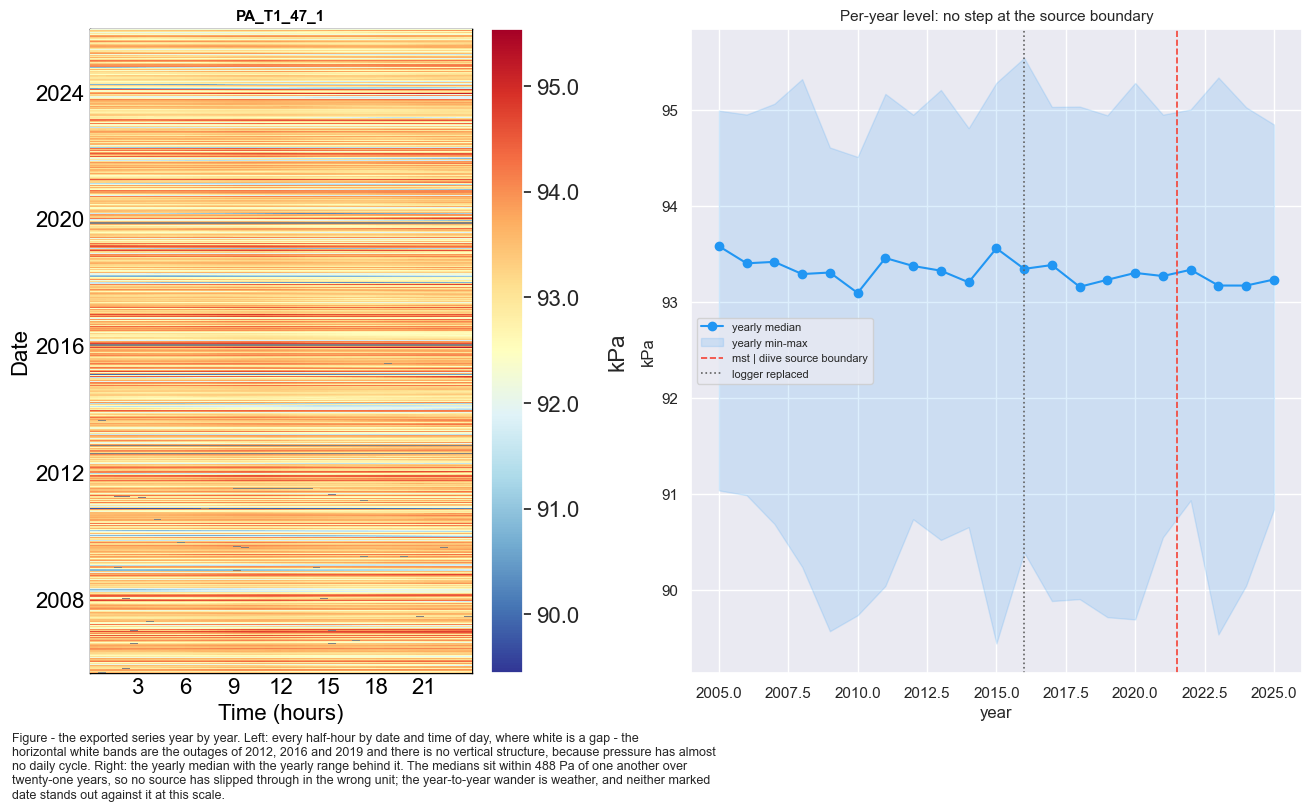

In [44]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['median'].plot(ax=axs[1], marker='o', color='#2196F3', label='yearly median')
axs[1].fill_between(_yr.index, _yr['min'], _yr['max'], color='#2196F3', alpha=.15,
                    label='yearly min-max')
axs[1].axvline(2021.5, color='#F44336', ls='--', lw=1.2, label='mst | diive source boundary')
axs[1].set_ylabel('kPa')
axs[1].set_xlabel('year')
axs[1].set_title('Per-year level: no step at the source boundary', fontsize=11)
axs[1].axvline(pd.Timestamp(ACQUISITION_CHANGE).year, color='#616161', ls=':', lw=1.2,
               label='logger replaced')
axs[1].legend(fontsize=8)
figcap(fig, f"the exported series year by year. Left: every half-hour by date and time of day, "
            f"where white is a gap - the horizontal white bands are the outages of 2012, 2016 and "
            f"2019 and there is no vertical structure, because pressure has almost no daily cycle. "
            f"Right: the yearly median with the yearly range behind it. The medians sit within "
            f"{1000 * float(_yr['median'].max() - _yr['median'].min()):.0f} Pa of one another over "
            f"twenty-one years, so no source has slipped through in the wrong unit; the year-to-"
            f"year wander is weather, and neither marked date stands out against it at this "
            f"scale.")

***

## 💾 Save to file

In [45]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\05_METEO_PA_2005-2025.parquet (0.028 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\05_METEO_PA_2005-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [46]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.3f} kPa")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} kPa")

assert list(_written.columns) == [VALCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write"
assert 85 < float(_written[VALCOL].median()) < 100, "median outside plausible kPa range"
print("\nWritten file verified.")

tabcap("the yearly median of the column as it was actually written to the parquet file, read back from disk rather than taken from the frame in memory")
display(_written[VALCOL].groupby(_written.index.year).median().round(3)
        .rename('yearly median (kPa)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\05_METEO_PA_2005-2025.parquet (0.007 seconds).

columns:   ['PA_T1_47_1']
index:     2005-09-02 00:15:00 -> 2025-12-31 23:45:00  (356,448 records)
measured:  352,438 (98.88%)
median:    93.306 kPa
min / max: 89.446 / 95.543 kPa

Written file verified.
Table - the yearly median of the column as it was actually written to the parquet file, read back
from disk rather than taken from the frame in memory



TIMESTAMP_MIDDLE
2005    93.584
2006    93.405
2007    93.420
2008    93.293
2009    93.309
2010    93.096
2011    93.460
2012    93.377
2013    93.328
2014    93.207
2015    93.561
2016    93.347
2017    93.387
2018    93.160
2019    93.234
2020    93.305
2021    93.272
2022    93.338
2023    93.174
2024    93.173
2025    93.236
Name: yearly median (kPa), dtype: float64

***

## End of notebook.

In [47]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-29 01:24:52
Finished: 2026-07-29 01:25:38
Runtime:  00:00:46 (hh:mm:ss)
